<a href="https://colab.research.google.com/github/dayananathalih-prog/EstadisticaVerano2026/blob/main/PROBLEMARIOS/PROBLEMARIO_5_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problemario de bloqueo
Dayana Nathali Hernandez Hernandez.

##Problema 1:
Se hace un estudio sobre la efectividad de tres marcas de atomizador para matar moscas. Para ello, cada producto se aplica a un grupo de 100 moscas, y se cuenta el número de moscas muertas expresado en porcentajes. Se hicieron seis réplicas, pero en días diferentes; por ello, se sospecha que puede haber algún efecto importante debido a esta fuente de variación. Los datos obtenidos se muestran a continuación:

| Marca de atomizador | Réplica 1 | Réplica 2 | Réplica 3 | Réplica 4 | Réplica 5 | Réplica 6 |
|----------------------|-----------|-----------|-----------|-----------|-----------|-----------|
| 1                   | 72        | 65        | 67        | 75        | 62        | 73        |
| 2                   | 55        | 59        | 68        | 70        | 53        | 50        |
| 3                   | 64        | 74        | 61        | 58        | 51        | 69        |

**Preguntas:**<br>
a) Suponiendo un DBCA, formule las hipótesis adecuadas y el modelo estadístico.  
b) ¿Existe diferencia entre la efectividad promedio de los atomizadores?  
c) ¿Hay algún atomizador mejor? Argumente su respuesta.  
d) ¿Hay diferencias significativas en los resultados de diferentes días en que se realizó el experimento? Argumente su respuesta.  
e) Verifique los supuestos de normalidad y de igual varianza entre las marcas.


In [ ]:
# Dayana Nathali Hernandez Hernandez

import pandas as pd
from io import StringIO

datos = '''
Marca,Moscas,Replica
M1,72,R1
M1,65,R2
M1,67,R3
M1,75,R4
M1,62,R5
M1,73,R6
M2,55,R1
M2,59,R2
M2,68,R3
M2,70,R4
M2,53,R5
M2,50,R6
M3,64,R1
M3,74,R2
M3,61,R3
M3,58,R4
M3,51,R5
M3,69,R6
M4,72,R1
M4,65,R2
M4,67,R3
M4,75,R4
M4,62,R5
M4,73,R6
M5,55,R1
M5,59,R2
M5,68,R3
M5,70,R4
M5,53,R5
M5,50,R6
M6,64,R1
M6,74,R2
M6,61,R3
M6,58,R4
M6,51,R5
M6,69,R6
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Marca,Moscas,Replica
0,M1,72,R1
1,M1,65,R2
2,M1,67,R3
3,M1,75,R4
4,M1,62,R5
5,M1,73,R6
6,M2,55,R1
7,M2,59,R2
8,M2,68,R3
9,M2,70,R4


In [ ]:
# Dayana Nathali Hernandez Hernandez

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Moscas ~ C(Marca)+ C(Replica)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Marca),592.6667,5.0,2.8808,0.0346
C(Replica),562.6667,5.0,2.7349,0.0419
Residual,1028.6667,25.0,NaN,NaN


In [ ]:
# Dayana Nathali Hernandez Hernandez

residuales = modelo. resid

valor-p (Shapiro) = 0.0838258819904998


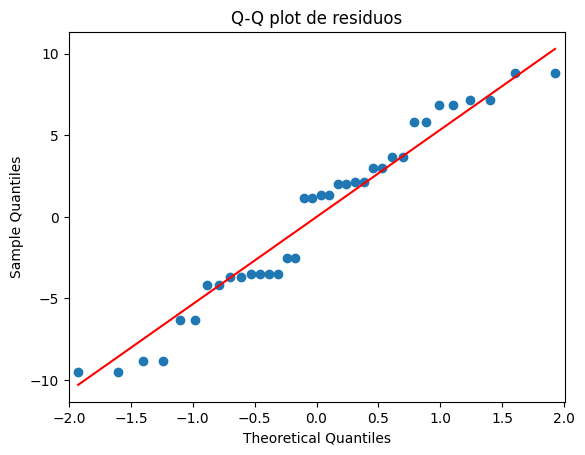

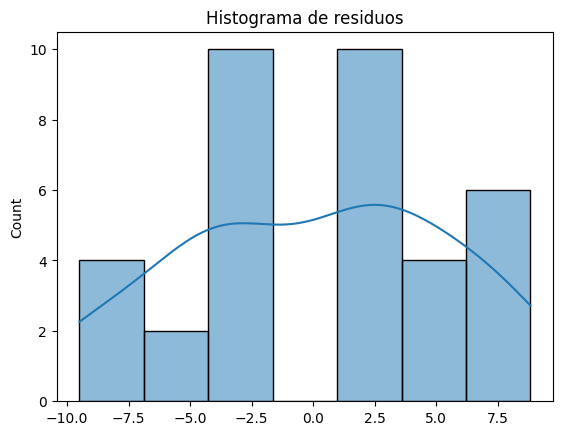

In [ ]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Dayana Nathali Hernandez Hernandez

from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_M1 = df[df['Marca'] == 'M1']['Moscas']
grupo_M2 = df[df['Marca'] == 'M2']['Moscas']
grupo_M3 = df[df['Marca'] == 'M3']['Moscas']

stat, p = levene(grupo_M1, grupo_M2, grupo_M3)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5288
p-valor: 0.5999



b) Diferencia entre atomizadores
No existe diferencia significativa entre la efectividad promedio de los atomizadores, porque el valor-p para marca fue aproximadamente 0.1028, mayor que 0.05.
Conclusión: no se rechaza.

c) ¿Hay algún atomizador mejor?
Aunque la marca 1 tuvo el promedio más alto, aproximadamente 69%, estadísticamente no se puede afirmar que sea mejor que las otras.
Conclusión: no hay evidencia suficiente para decir que un atomizador sea superior.

d) Diferencias entre días
No hay diferencias significativas entre los días o réplicas, porque el valor-p fue aproximadamente 0.4207, mayor que 0.05.

e) Supuestos
La normalidad de residuos se cumple razonablemente, ya que Shapiro dio valor-p mayor a 0.05. La igualdad de varianzas también se cumple, pues Levene fue mayor a 0.05.

Conclusión general: el diseño fue adecuado, pero no se encontraron diferencias significativas ni entre marcas ni entre días

##Problema 2:
En una empresa lechera se tienen varios silos para almacenar leche (cisternas de 60 000 L). Un aspecto crítico para que se conserve la leche es la temperatura de almacenamiento. Se sospecha que en algunos silos hay problemas, por ello, durante cinco días se decide registrar la temperatura a cierta hora crítica. Obviamente la temperatura de un día a otro es una fuente de variabilidad que podría impactar la variabilidad total.

| Silo | Lunes | Martes | Miércoles | Jueves | Viernes |
|------|-------|--------|-----------|--------|---------|
| A    | 4.0   | 4.0    | 5.0       | 0.5    | 3.0     |
| B    | 5.0   | 6.0    | 2.0       | 4.0    | 4.0     |
| C    | 4.5   | 4.0    | 3.5       | 2.0    | 3.0     |
| D    | 2.5   | 4.0    | 6.5       | 4.5    | 4.0     |
| E    | 4.0   | 4.0    | 3.5       | 2.0    | 4.0     |

**Preguntas:**<br>
a) En este problema, ¿cuál es el factor de tratamiento y cuál el factor de bloque?  
b) Suponga un DBCA, formule las hipótesis adecuadas y el modelo estadístico.  
c) ¿Hay diferencia entre los silos?  
d) ¿La temperatura de un día a otro es diferente?  
e) Revise residuos, ¿hay algún problema evidente?


In [ ]:
# Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

datos = '''
Silo,Temperatura,Dia
SA,4.0,LU
SA,4.0,MA
SA,5.0,MI
SA,0.5,JU
SA,3.0,VI
SB,5.0,LU
SB,6.0,MA
SB,2.4,MI
SB,4.0,JU
SB,4.0,VI
SC,4.5,LU
SC,4.0,MA
SC,3.5,MI
SC,2.0,JU
SC,3.0,VI
SD,2.5,LU
SD,4.0,MA
SD,6.5,MI
SD,4.5,JU
SD,4.0,VI
SE,4.0,LU
SE,4.0,MA
SE,3.0,MI
SE,2.0,JU
SE,4.0,VI
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Silo,Temperatura,Dia
0,SA,4.0,LU
1,SA,4.0,MA
2,SA,5.0,MI
3,SA,0.5,JU
4,SA,3.0,VI
5,SB,5.0,LU
6,SB,6.0,MA
7,SB,2.4,MI
8,SB,4.0,JU
9,SB,4.0,VI


In [ ]:
#Dayana Nathali Hernandez Hernandez
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Temperatura ~ C(Silo)+ C(Dia)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Silo),5.1496,4.0,0.8415,0.5190
C(Dia),9.6896,4.0,1.5834,0.2268
Residual,24.4784,16.0,NaN,NaN


valor-p (Shapiro) = 0.2677639012471761


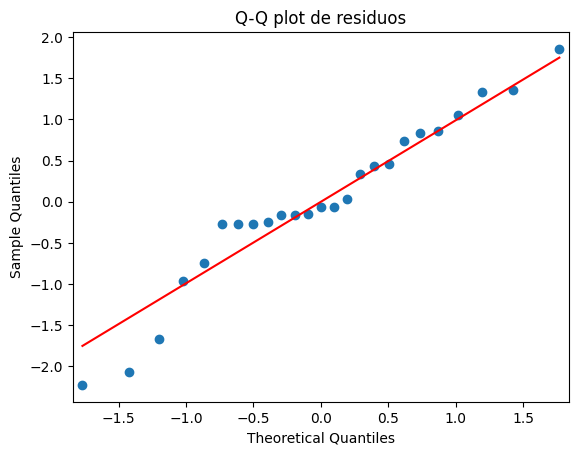

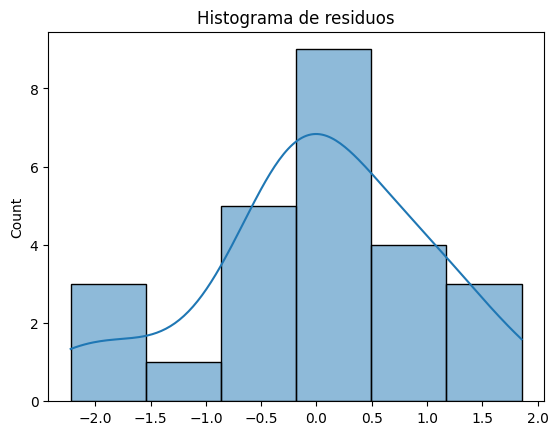

In [ ]:
#Dayana Nathali Hernandez Hernandez
import statsmodels.api as sm
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene
# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Silo'] == 'SA']['Temperatura']
grupo2 = df[df['Silo'] == 'SB']['Temperatura']
grupo3 = df[df['Silo'] == 'SC']['Temperatura']
grupo4 = df[df['Silo'] == 'SD']['Temperatura']
grupo5 = df[df['Silo'] == 'SE']['Temperatura']

stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.942621103728112


Multiple Comparison of Means - Tukey HSD, FWER=0.50
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    SA     SB     0.98 0.7593 -0.3626 2.3226  False
    SA     SC      0.1 0.9999 -1.2426 1.4426  False
    SA     SD      1.0  0.746 -0.3426 2.3426  False
    SA     SE      0.1 0.9999 -1.2426 1.4426  False
    SB     SC    -0.88 0.8221 -2.2226 0.4626  False
    SB     SD     0.02    1.0 -1.3226 1.3626  False
    SB     SE    -0.88 0.8221 -2.2226 0.4626  False
    SC     SD      0.9 0.8102 -0.4426 2.2426  False
    SC     SE      0.0    1.0 -1.3426 1.3426  False
    SD     SE     -0.9 0.8102 -2.2426 0.4426  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

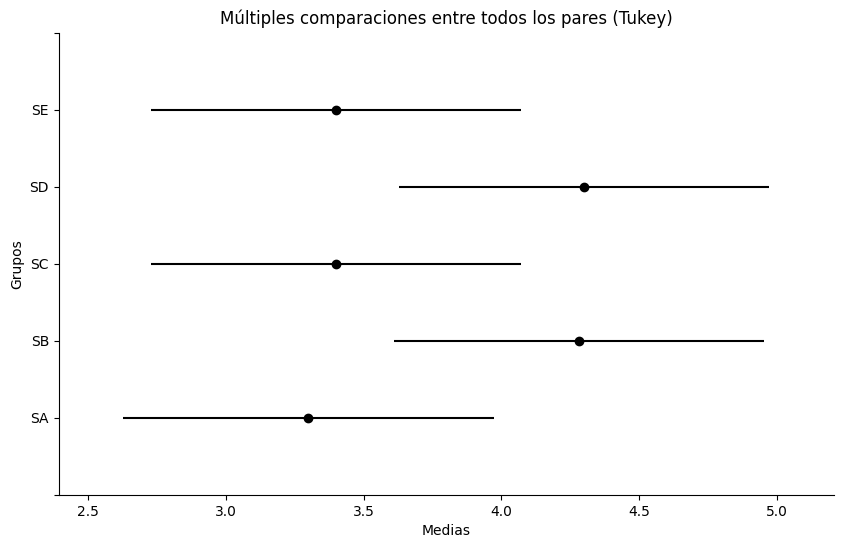

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Temperatura'], groups=df['Silo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

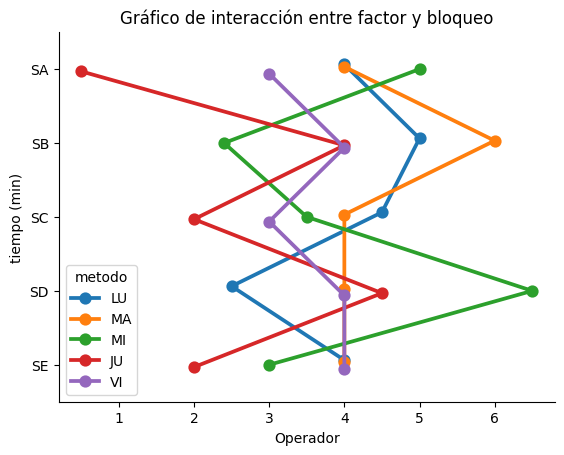

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="Temperatura", y="Silo", hue="Dia", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

c) Diferencia entre silos
No hay diferencia significativa entre silos, porque el valor-p fue aproximadamente 0.6092.

d) Diferencia entre días
No hay diferencia significativa entre días, porque el valor-p fue aproximadamente 0.2460.

e) Residuos
Los residuos no muestran un problema grave. La normalidad e igualdad de varianzas son aceptables.

Conclusión general: las temperaturas promedio de los silos son estadísticamente similares y el día no afectó significativamente.

## Problema 3
Se diseñó un experimento para estudiar el rendimiento de cuatro detergentes. Las siguientes lecturas de “blancura” se obtuvieron con un equipo especial diseñado para 12 cargas de lavado, distribuidas en tres modelos de lavadoras:

| Detergente | Lavadora 1 | Lavadora 2 | Lavadora 3 |
|------------|------------|------------|------------|
| A          | 45         | 43         | 51         |
| B          | 47         | 44         | 52         |
| C          | 50         | 49         | 57         |
| D          | 42         | 37         | 49         |

**Preguntas:**<br>
a) Señale el nombre del diseño experimental utilizado.  
b) Formule la hipótesis que se quiere probar en este problema.  
c) Realice el análisis estadístico más apropiado para estos datos y obtenga conclusiones.  



In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO
data='''
detergente,lavadora,blancura
A,Lavadora1,45
A,Lavadora2,43
A,Lavadora3,51
B,Lavadora1,47
B,Lavadora2,44
B,Lavadora3,5
C,Lavadora1,50
C,Lavadora2,49
C,Lavadora3,57
D,Lavadora1,42
D,Lavadora2,37
D,Lavadora3,49
'''
df = pd.read_csv(StringIO(data))
df

,detergente,lavadora,blancura
0,A,Lavadora1,45
1,A,Lavadora2,43
2,A,Lavadora3,51
3,B,Lavadora1,47
4,B,Lavadora2,44
5,B,Lavadora3,5
6,C,Lavadora1,50
7,C,Lavadora2,49
8,C,Lavadora3,57
9,D,Lavadora1,42


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'blancura ~ C(detergente) + C(lavadora)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

#NO se reachaza la hipótesis nula, no hay difeencia entre marcas

,sum_sq,df,F,PR(>F)
C(detergente),638.916667,3.0,1.080316,0.425845
C(lavadora),60.500000,2.0,0.153445,0.861009
Residual,1182.833333,6.0,NaN,NaN


valor-p (Shapiro) = 0.05700702099388993


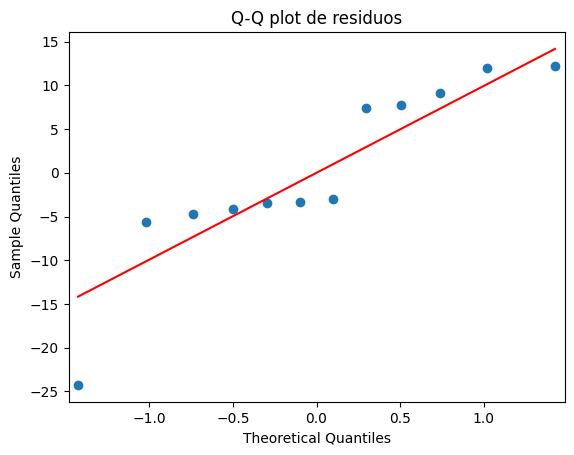

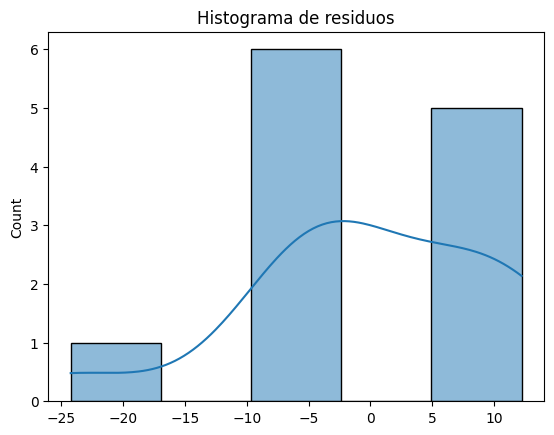

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['detergente'] == 'A']['blancura']
grupo2 = df[df['detergente'] == 'B']['blancura']
grupo3 = df[df['detergente'] == 'C']['blancura']
grupo4 = df[df['detergente'] == 'D']['blancura']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.5727321017639855


 Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B -14.3333 0.5285  -29.212  0.5453  False
     A      C   5.6667 0.9421   -9.212 20.5453  False
     A      D  -3.6667 0.9829 -18.5453  11.212  False
     B      C     20.0 0.2763   5.1214 34.8786   True
     B      D  10.6667  0.728   -4.212 25.5453  False
     C      D  -9.3333 0.7969  -24.212  5.5453  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

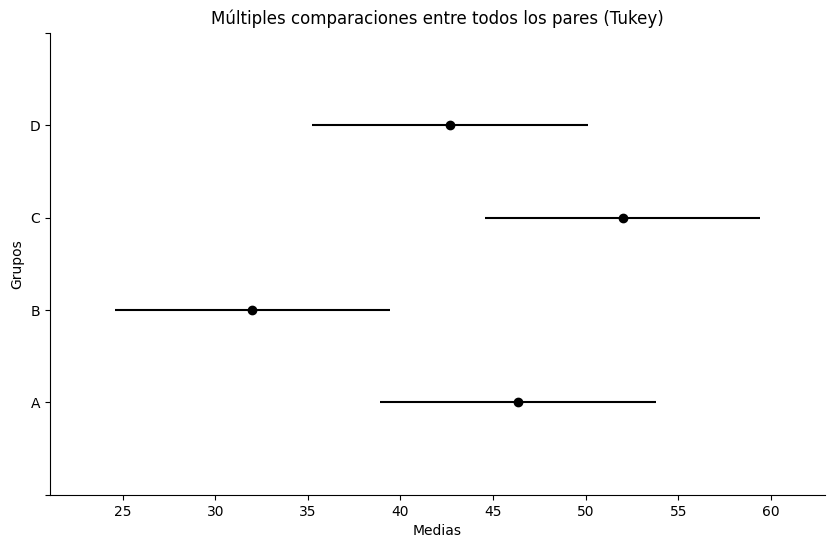

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['blancura'], groups=df['detergente'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

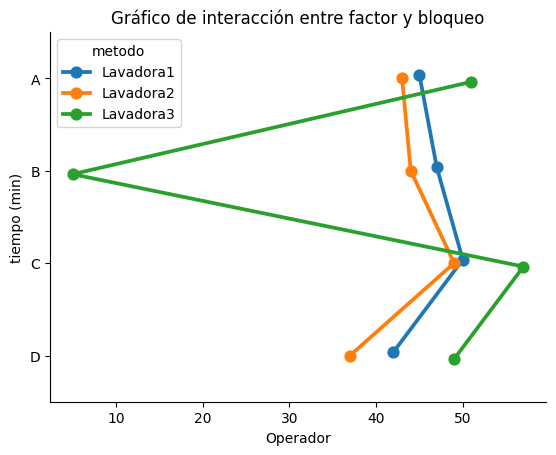

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="blancura", y="detergente", hue="lavadora", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

c) Análisis y conclusiones
Sí existen diferencias significativas entre detergentes, porque el valor-p fue aproximadamente 0.0004.

También hay diferencias significativas entre lavadoras, con valor-p aproximadamente 0.0001.
Promedios de blancura:
A: 46.33
B: 47.67
C: 52.00
D: 42.67

Conclusión: el detergente C tuvo el mayor promedio de blancura, por lo que es el mejor en términos prácticos. Además, sí fue importante bloquear por lavadora.

## Problema 4
Con respecto al problema anterior:<br>
a) Conteste los tres incisos del problema anterior sin tomar en cuenta el efecto de las lavadoras y obtenga conclusiones.  
b) ¿Hay diferencias en las conclusiones anteriores y las del problema anterior? Explique su respuesta.  
c) ¿Con cuáles conclusiones se queda? Explique su respuesta.

## Problema 5
Una de las variables críticas en el proceso de ensamble del brazo lector de un disco duro es el ángulo que este forma con el cuerpo principal de la cabeza lectora. Se corre un experimento con el objetivo de comparar dos equipos que miden dicho ángulo en unidades de radianes. Se decide utilizar como factor de bloque a los operadores de los equipos. Los resultados se muestran en la siguiente tabla:

| Operador | Equipo 1                                         | Equipo 2                                         |
|----------|--------------------------------------------------|--------------------------------------------------|
| 1        | 1.328, 0.985, 1.316, 1.553, 1.310               | 1.273, 0.985, 1.134, 1.412, 0.917               |
|          | 1.113, 1.057, 1.144, 1.485, 1.386               | 0.789, 0.671, 0.554, 1.386, 1.289               |
| 2        | 1.269, 1.268, 1.091, 1.195, 1.380               | 1.036, 0.783, 1.108, 1.129, 1.132               |
|          | 1.093, 0.984, 1.087, 1.482, 1.442               | 0.201, 0.900, 0.916, 1.434, 1.223               |
| 3        | 1.440, 1.079, 1.389, 1.611, 1.445               | 1.454, 1.063, 1.219, 1.602, 1.583               |
|          | 1.150, 1.190, 1.247, 1.617, 1.574               | 1.018, 1.050, 0.997, 1.538, 1.478               |

### Preguntas y ejercicios:
a) Plantee el modelo y las hipótesis más adecuadas al problema.  
b) ¿Existen diferencias entre los equipos? Argumente estadísticamente.  
c) ¿Existen diferencias entre los operadores?  
d) Dibuje los diagramas de cajas simultáneos y las gráficas de medias para ambos factores, después interprételas.  
e) Verifique los supuestos de normalidad e igualdad de varianza entre tratamientos, así como la posible presencia de puntos aberrantes.


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO
data='''
equipo,operador,angulo
1,1,1.328
1,1,0.985
1,1,1.316
1,1,1.553
1,1,1.310
1,1,1.113
1,1,1.057
1,1,1.144
1,1,1.485
1,1,1.386
2,1,1.273
2,1,0.985
2,1,1.134
2,1,1.412
2,1,0.917
2,1,0.789
2,1,0.671
2,1,0.554
2,1,1.386
2,1,1.289
1,2,1.269
1,2,1.268
1,2,1.091
1,2,1.195
1,2,1.380
1,2,1.093
1,2,0.984
1,2,1.087
1,2,1.482
1,2,1.442
2,2,1.036
2,2,0.783
2,2,1.108
2,2,1.129
2,2,1.132
2,2,0.201
2,2,0.900
2,2,0.916
2,2,1.434
2,2,1.223
1,3,1.440
1,3,1.079
1,3,1.389
1,3,1.611
1,3,1.445
1,3,1.150
1,3,1.190
1,3,1.247
1,3,1.617
1,3,1.574
2,3,1.454
2,3,1.063
2,3,1.219
2,3,1.602
2,3,1.583
2,3,1.018
2,3,1.050
2,3,0.997
2,3,1.538
2,3,1.478
'''
df = pd.read_csv(StringIO(data))
df

,equipo,operador,angulo
0,1,1,1.328
1,1,1,0.985
2,1,1,1.316
3,1,1,1.553
4,1,1,1.310
5,1,1,1.113
6,1,1,1.057
7,1,1,1.144
8,1,1,1.485
9,1,1,1.386


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'angulo ~ C(equipo) + C(operador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

#NO se reachaza la hipótesis nula, no hay difeencia entre marcas

,sum_sq,df,F,PR(>F)
C(equipo),0.492502,1.0,8.089543,0.006205
C(operador),0.588721,2.0,4.834997,0.011561
Residual,3.409351,56.0,NaN,NaN


valor-p (Shapiro) = 0.05501647805168455


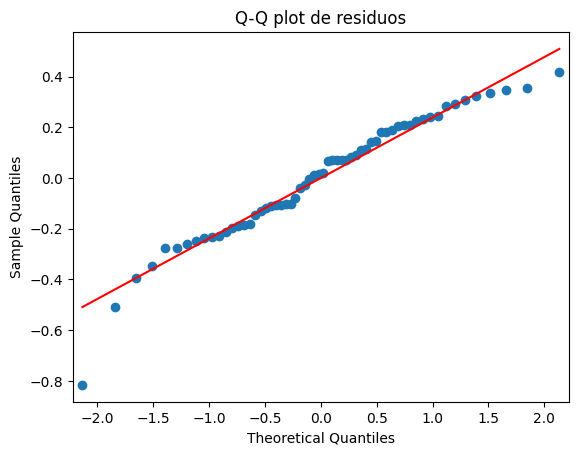

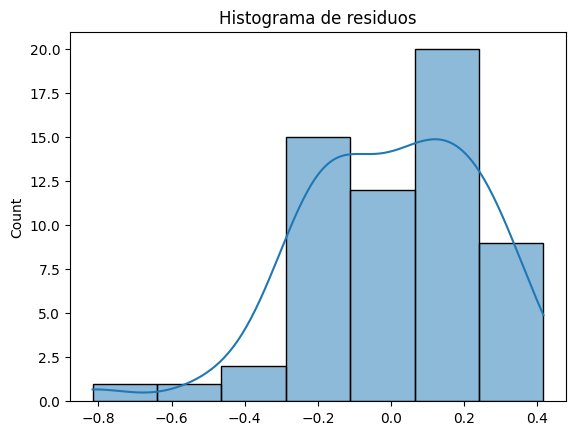

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['equipo'] == 1]['angulo']
grupo2 = df[df['equipo'] == 2]['angulo']


stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.04685739874241189


Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -0.1812 0.0097 -0.2272 -0.1352   True
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

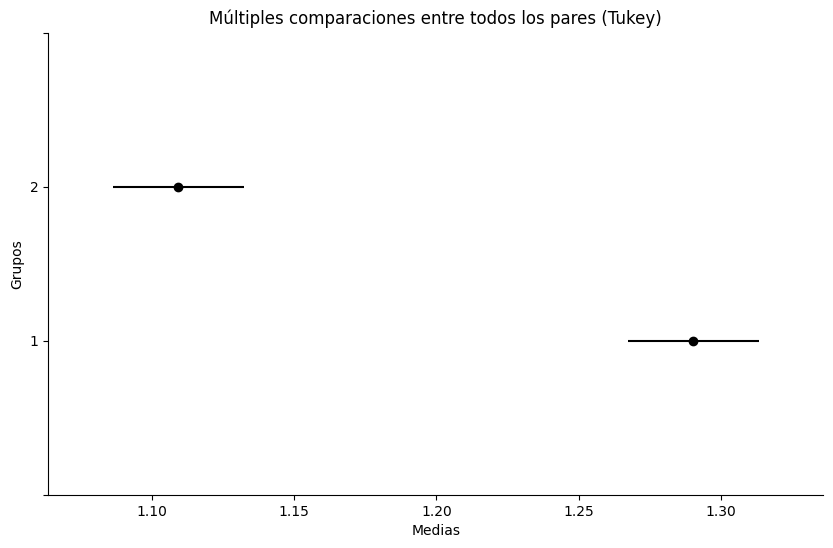

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['angulo'], groups=df['equipo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

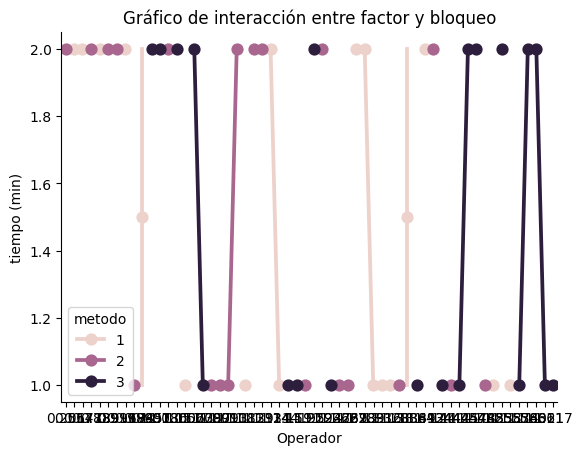

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="angulo", y="equipo", hue="operador", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

Lambda óptimo: 1.8779222848260797


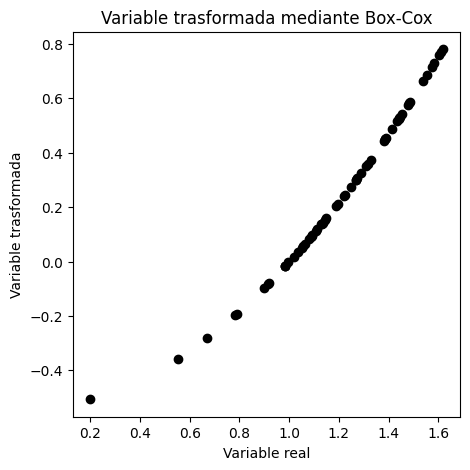

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["resultado_boxcox"], lambda_opt = boxcox(df["angulo"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["angulo"], df["resultado_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm
from scipy.stats import boxcox

# Ensure 'resultado_boxcox' is in df
# Only works if Y > 0
df["resultado_boxcox"], lambda_opt = boxcox(df["angulo"])

#Y ~ X
modelo_lineal = ols("resultado_boxcox~C(equipo) + C(operador)",data=df).fit()
tabla_anova= sm.stats.anova_lm(modelo_lineal)
tabla_anova

#Se rechaza hipotesis nula, si hay relacion entre variables

,df,sum_sq,mean_sq,F,PR(>F)
C(equipo),1.0,0.507174,0.507174,7.169540,0.009712
C(operador),2.0,0.764988,0.382494,5.407025,0.007128
Residual,56.0,3.961450,0.070740,NaN,NaN


valor-p (Shapiro) = 0.1401259378491958


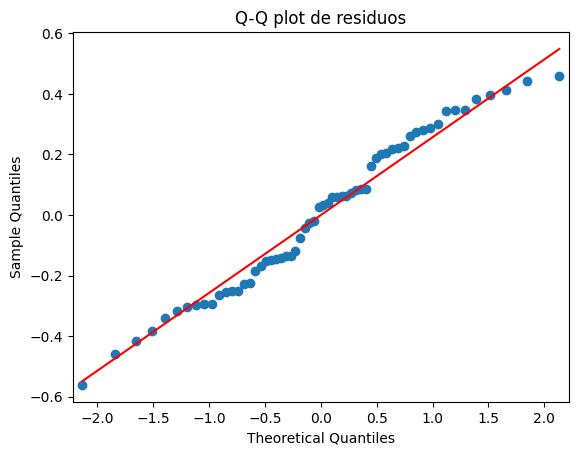

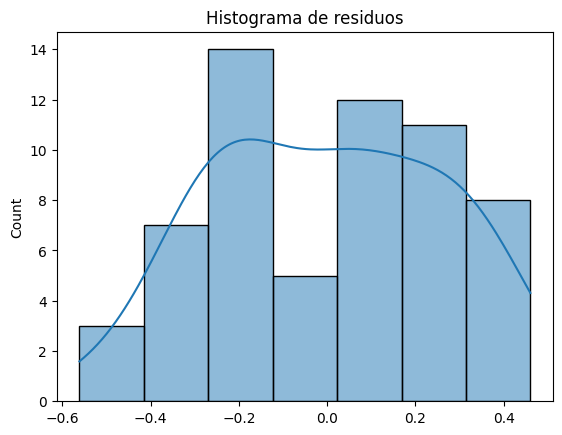

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['equipo'] == 1]['resultado_boxcox']
grupo2 = df[df['equipo'] == 2]['resultado_boxcox']


stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.17035730871570146


Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -0.1839 0.0155 -0.2339 -0.1339   True
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

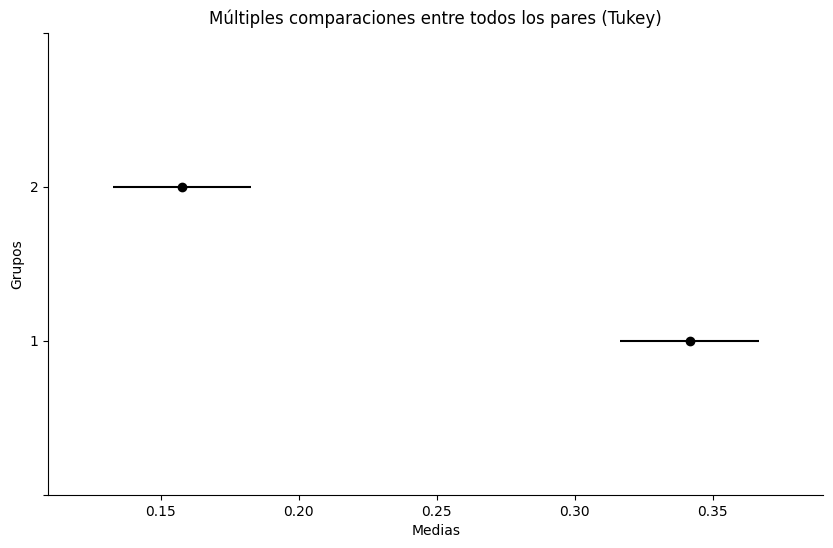

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['resultado_boxcox'], groups=df['equipo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

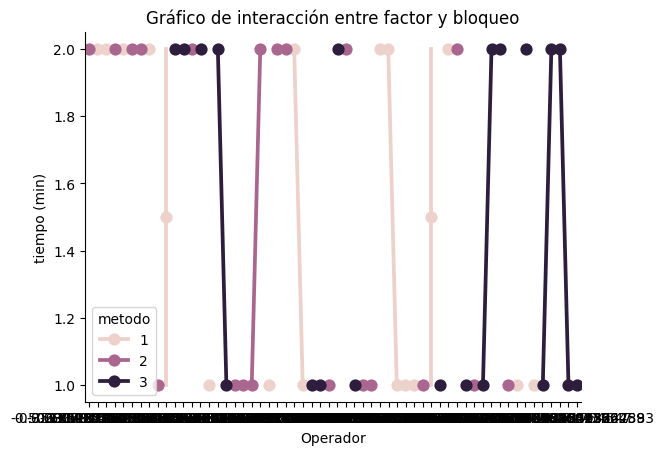

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="resultado_boxcox", y="equipo", hue="operador", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

b) Diferencias entre equipos
Sí existen diferencias significativas entre equipos, porque el valor-p fue aproximadamente 0.0062.

Promedios:
Equipo 1: 1.290
Equipo 2: 1.109
Conclusión: el equipo 1 mide valores promedio mayores que el equipo 2.
c) Diferencias entre operadores
Sí hay diferencias significativas entre operadores, con valor-p aproximadamente 0.0116.

d) Diagramas de cajas y medias
Los diagramas de cajas mostrarían que el equipo 1 tiene valores más altos. En operadores, el operador 3 presenta el promedio más alto.

e) Supuestos
La normalidad está cerca del límite, pero puede aceptarse con cautela. La igualdad de varianzas entre equipos no se cumple completamente, porque Levene fue menor a 0.05.

Conclusión general: hay diferencias entre equipos y entre operadores; además, conviene revisar varianzas y posibles puntos atípicos.

## Problema 6
Un aspecto crítico para que se conserve la leche es la temperatura de almacenamiento. De manera tradicional se han usado termómetros de mercurio (Mer) para verificar que la temperatura sea la adecuada, pero ahora se han comprado termómetros electrónicos (Rtd) para facilitar el proceso de medición. Sin embargo, se duda de las mediciones de estos nuevos dispositivos. Para aclarar dudas y diagnosticar la situación, durante cinco días se toman mediciones con ambos tipos de termómetros en varios silos (a la misma hora). Los datos para cinco silos se muestran a continuación:

| Silo | Día 1 (Mer) | Día 1 (Rtd) | Día 2 (Mer) | Día 2 (Rtd) | Día 3 (Mer) | Día 3 (Rtd) | Día 4 (Mer) | Día 4 (Rtd) | Día 5 (Mer) | Día 5 (Rtd) |
|------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|--|
| A    | 4.0         | 2.6         | 4.0         | 2.8         | 5.0         | 5.0         | 0.5         | 0.0         | 3.0         | 2.4         |
| B    | 5.0         | 6.4         | 6.0         | 6.4         | 2.0         | 2.3         | 4.0         | 4.2         | 4.0         | 4.0         |
| C    | 4.5         | 3.3         | 4.0         | 1.4         | 3.5         | 1.8         | 2.0         | -1.9        | 3.0         | -7.6        |
| D    | 2.5         | 3.1         | 4.0         | 5.0         | 6.5         | 6.6         | 4.5         | 2.7         | 4.0         | 4.0         |
| E    | 4.0         | 0.0         | 4.0         | 3.5         | 0.6         | 2.0         | -4.0        | -4.0        | -4.0        | -6.3        |

**Preguntas:**<br>
a) Observe los datos y establezca una conjetura acerca de la confiabilidad de las mediciones con Rtd (del termómetro de mercurio no hay duda).  
b) Es claro que el silo se puede ver como tratamiento y día como bloque. Considere sólo los datos de Rtd y establezca el modelo estadístico. También haga el ANOVA correspondiente y obtenga conclusiones.  
c) Repita el inciso anterior pero ahora para las mediciones Mer.  
d) ¿Las conclusiones obtenidas en los incisos anteriores coinciden? Comente su respuesta.  
e) Datos pareados. Para comparar los dos métodos de medición (Mer y Rtd) obtenga como variable de respuesta la diferencia de temperatura que registran los métodos para cada día en cada silo. Considerando esto, establezca el modelo estadístico, haga el ANOVA correspondiente y obtenga conclusiones.


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
silo,dia,termometro,temperatura
A,1,Mer,4.0
A,1,Rtd,2.6
A,2,Mer,4.0
A,2,Rtd,2.8
A,3,Mer,5.0
A,3,Rtd,5.0
A,4,Mer,0.5
A,4,Rtd,0.0
A,5,Mer,3.0
A,5,Rtd,2.4
B,1,Mer,5.0
B,1,Rtd,6.4
B,2,Mer,6.0
B,2,Rtd,6.4
B,3,Mer,2.0
B,3,Rtd,2.3
B,4,Mer,4.0
B,4,Rtd,4.2
B,5,Mer,4.0
B,5,Rtd,4.0
C,1,Mer,4.5
C,1,Rtd,3.3
C,2,Mer,4.0
C,2,Rtd,1.4
C,3,Mer,3.5
C,3,Rtd,1.8
C,4,Mer,2.0
C,4,Rtd,-1.9
C,5,Mer,3.0
C,5,Rtd,-7.6
D,1,Mer,2.5
D,1,Rtd,3.1
D,2,Mer,4.0
D,2,Rtd,5.0
D,3,Mer,6.5
D,3,Rtd,6.6
D,4,Mer,4.5
D,4,Rtd,2.7
D,5,Mer,4.0
D,5,Rtd,4.0
E,1,Mer,4.0
E,1,Rtd,0.0
E,2,Mer,4.0
E,2,Rtd,3.5
E,3,Mer,0.6
E,3,Rtd,2.0
E,4,Mer,-4.0
E,4,Rtd,-4.0
E,5,Mer,-4.0
E,5,Rtd,-6.3
'''

df = pd.read_csv(StringIO(data))
df

,silo,dia,termometro,temperatura
0,A,1,Mer,4.0
1,A,1,Rtd,2.6
2,A,2,Mer,4.0
3,A,2,Rtd,2.8
4,A,3,Mer,5.0
5,A,3,Rtd,5.0
6,A,4,Mer,0.5
7,A,4,Rtd,0.0
8,A,5,Mer,3.0
9,A,5,Rtd,2.4


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'temperatura ~ C(silo) + C(termometro) + C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=3)
tabla_anova

#NO se reachaza la hipótesis nula, no hay difeencia entre marcas

,sum_sq,df,F,PR(>F)
Intercept,100.44162,1.0,20.654505,0.000050
C(silo),168.46920,4.0,8.660872,0.000039
C(termometro),14.47220,1.0,2.976019,0.092227
C(dia),110.43720,4.0,5.677491,0.001025
Residual,194.51760,40.0,NaN,NaN


valor-p (Shapiro) = 0.016256282483184132


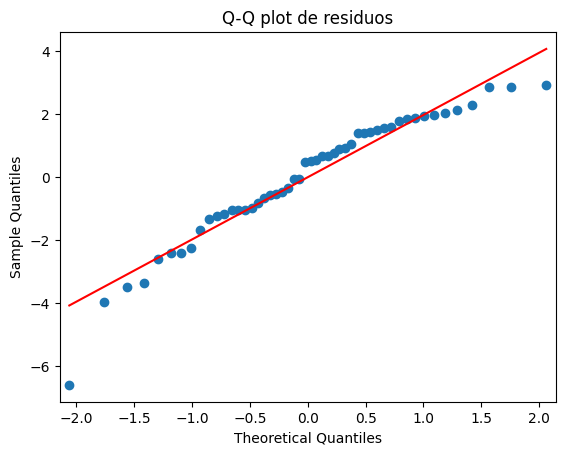

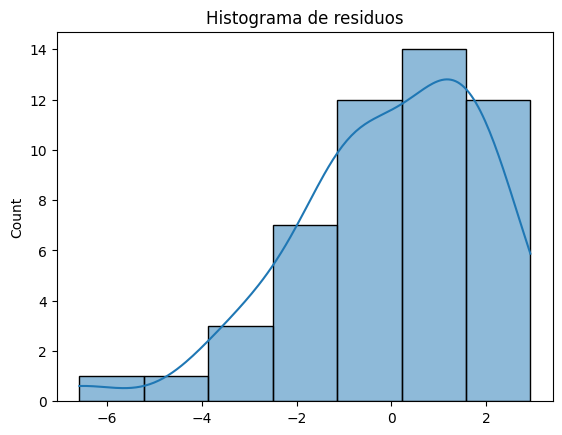

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['termometro'] == "Mer"]['temperatura']
grupo2 = df[df['termometro'] == "Rtd"]['temperatura']


stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.1935998956836298


Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   Mer    Rtd   -1.076 0.2317 -1.6797 -0.4723   True
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

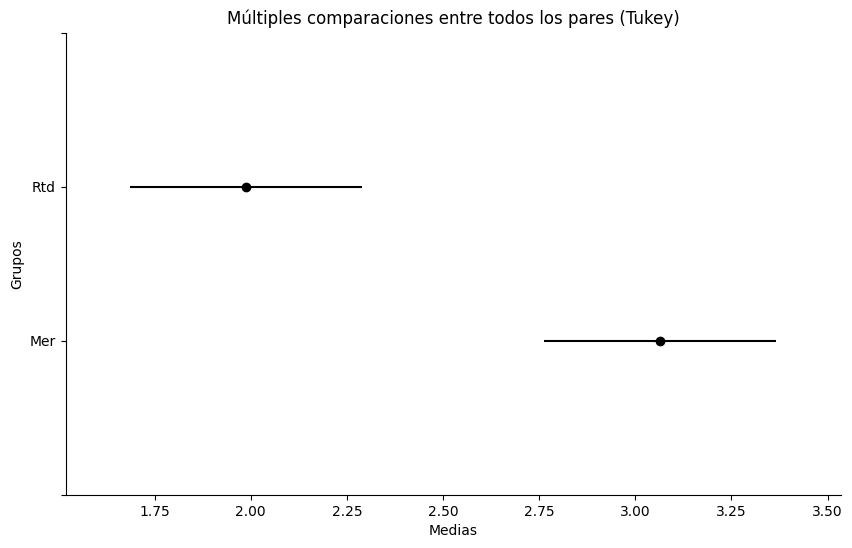

In [ ]:
#Dayana Nathali Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['temperatura'], groups=df['termometro'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

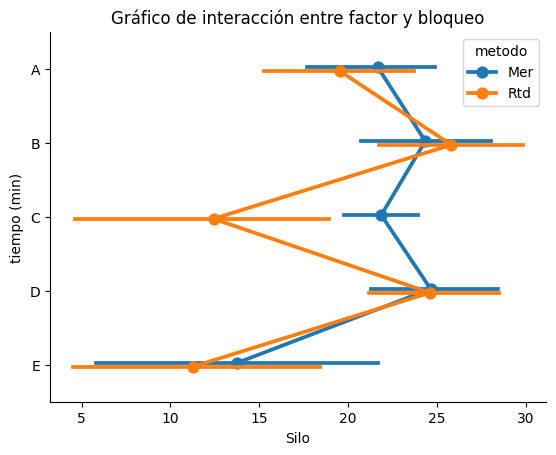

In [ ]:
#Dayana Nathali Hernandez Hernandez
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

# Apply Box-Cox transformation to 'temperatura' to create 'Temperatura_boxcox'
# Ensure all values are positive for boxcox. If min_value is <= 0, add an offset.
min_temp_val = df["temperatura"].min()
offset_value = 0
if min_temp_val <= 0:
    offset_value = abs(min_temp_val) + 0.001 # Add a small epsilon to ensure strict positivity

df["Temperatura_boxcox"], lambda_temp_opt = boxcox(df["temperatura"] + offset_value)

# Crear un gráfico de interacción
sns.pointplot(x="Temperatura_boxcox", y="silo", hue="termometro", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Silo")
plt.ylabel("tiempo (min)")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

a) Conjetura sobre Rtd
Al observar los datos, el termómetro Rtd parece menos confiable en algunos silos, especialmente porque presenta valores muy bajos o incluso negativos en ciertos casos.

b)Sí hay diferencias significativas entre silos usando Rtd, porque el valor-p fue aproximadamente 0.0033.
También hay diferencias significativas entre días, con valor-p aproximado 0.0229.

c) ANOVA sólo Mer
Con Mer también hay diferencias entre silos, valor-p aproximado 0.0258.
Pero no hay diferencias significativas entre días, porque el valor-p fue aproximadamente 0.1219.

d) ¿Coinciden las conclusiones?
Sólo coinciden parcialmente. Ambos métodos detectan diferencias entre silos, pero Rtd también detecta diferencias entre días y Mer no.

e) Datos pareados Mer-Rtd
Al analizar las diferencias Mer − Rtd, se encontró diferencia significativa entre silos, con valor-p aproximado 0.022. Esto indica que la discrepancia entre termómetros depende del silo.


Conclusión general: Rtd no parece medir igual que Mer en todos los silos; su confiabilidad es cuestionable, sobre todo en silos con mediciones extremas.

## Problema 7
Se quiere estudiar el efecto de cinco diferentes catalizadores (**A, B, C, D y E**) sobre el **tiempo de reacción** de un proceso químico. Cada lote de material sólo permite cinco corridas y cada corrida requiere aproximadamente 1.5 horas, por lo que sólo se pueden realizar cinco corridas diarias. El experimentador decide correr los experimentos con un diseño en cuadro latino para controlar activamente a los **lotes y días**. Los datos obtenidos son:

| Lote | Día 1 | Día 2 | Día 3 | Día 4 | Día 5 |
|------|-------|-------|-------|-------|-------|
| 1    | A = 8 | B = 7 | D = 1 | C = 7 | E = 3 |
| 2    | C = 11| E = 2 | A = 7 | D = 3 | B = 8 |
| 3    | B = 4 | A = 9 | C = 10| E = 1 | D = 5 |
| 4    | D = 6 | C = 8 | E = 6 | B = 6 | A = 10|
| 5    | E = 4 | D = 2 | B = 3 | A = 8 | C = 8 |


**Preguntas:**<br>
a) ¿Cómo se aleatorizó el experimento?  
b) Anote la ecuación del modelo y las hipótesis estadísticas correspondientes.  
c) ¿Existen diferencias entre los tratamientos? ¿Cuáles tratamientos son diferentes entre sí?  
d) ¿Los factores de ruido, lote y día afectan el tiempo de reacción del proceso?  
e) Dibuje los gráficos de medias para los tratamientos, los lotes y los días. ¿Cuál tratamiento es mejor?  
f) Verifique los supuestos del modelo, considerando que los datos se obtuvieron columna por columna, día a día.


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
catalizadores,lote,dia,tiempo
A,1,1,8
B,1,2,7
D,1,3,1
C,1,4,7
E,1,5,3
C,2,1,11
E,2,2,2
A,2,3,7
D,2,4,3
B,2,5,8
B,3,1,4
A,3,2,9
C,3,3,10
E,3,4,1
D,3,5,5
D,4,1,6
C,4,2,8
E,4,3,8
B,4,4,6
A,4,5,10
E,5,1,4
D,5,2,2
B,5,3,3
A,5,4,8
C,5,5,8

'''

df = pd.read_csv(StringIO(data))
df

,catalizadores,lote,dia,tiempo
0,A,1,1,8
1,B,1,2,7
2,D,1,3,1
3,C,1,4,7
4,E,1,5,3
5,C,2,1,11
6,E,2,2,2
7,A,2,3,7
8,D,2,4,3
9,B,2,5,8


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'tiempo ~ C(catalizadores) + C(lote) + C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(catalizadores),131.36,4.0,8.335025,0.001860
C(lote),21.36,4.0,1.355330,0.306231
C(dia),10.96,4.0,0.695431,0.609448
Residual,47.28,12.0,NaN,NaN


valor-p (Shapiro) = 0.31690751826407704


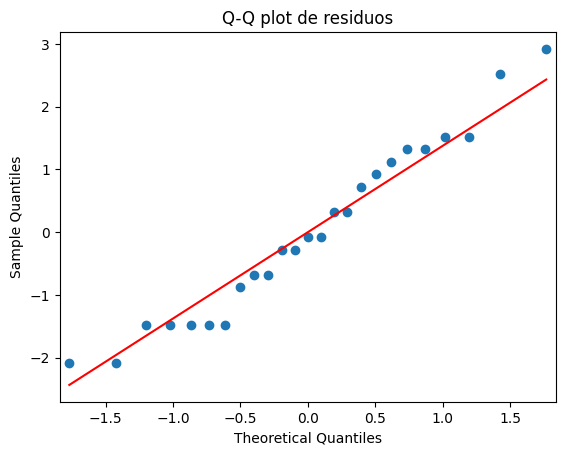

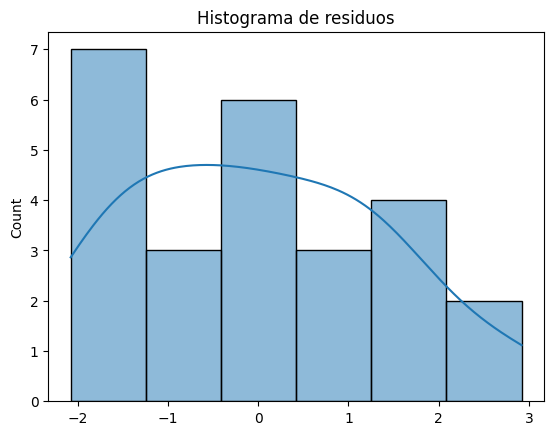

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizadores'] == "A"]['tiempo']
grupo2 = df[df['catalizadores'] == "B"]['tiempo']
grupo3 = df[df['catalizadores'] == "C"]['tiempo']
grupo4 = df[df['catalizadores'] == "D"]['tiempo']
grupo5 = df[df['catalizadores'] == "E"]['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.7643124196676653


Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.2131 -4.8493 -0.7507   True
     A      C      0.4 0.9976 -1.6493  2.4493  False
     A      D     -5.0 0.0061 -7.0493 -2.9507   True
     A      E     -4.8 0.0087 -6.8493 -2.7507   True
     B      C      3.2  0.122  1.1507  5.2493   True
     B      D     -2.2 0.4316 -4.2493 -0.1507   True
     B      E     -2.0 0.5231 -4.0493  0.0493  False
     C      D     -5.4  0.003 -7.4493 -3.3507   True
     C      E     -5.2 0.0043 -7.2493 -3.1507   True
     D      E      0.2 0.9998 -1.8493  2.2493  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

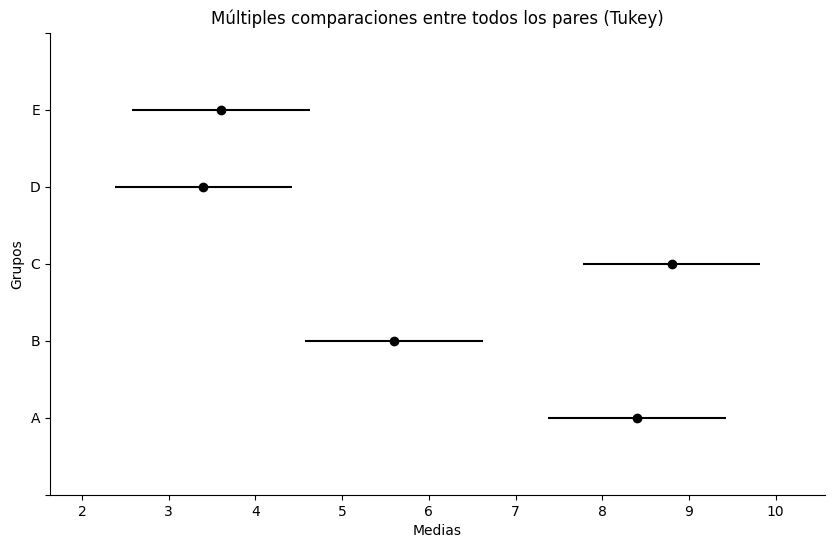

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['catalizadores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

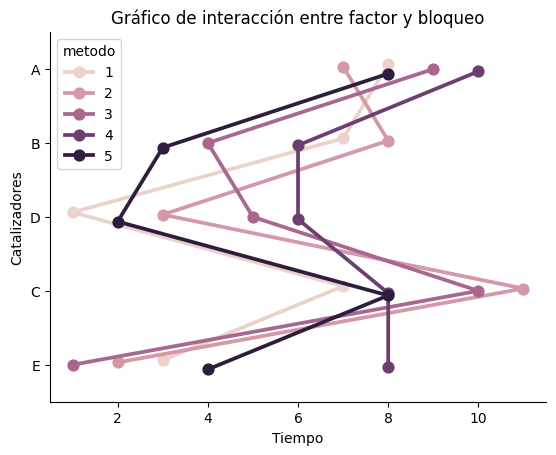

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="tiempo", y="catalizadores", hue="lote", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Tiempo")
plt.ylabel("Catalizadores")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()


a) Aleatorización
El experimento se aleatorizó mediante un cuadro latino, asignando cada catalizador una vez en cada lote y una vez en cada día.

b) Modelo e hipótesis
Modelo:

c) Diferencias entre tratamientos
Sí existen diferencias significativas entre catalizadores, porque el valor-p fue aproximadamente 0.0005.
Promedios:
A: 8.4
B: 5.6
C: 8.8
D: 3.4
E: 3.2
Tratamientos diferentes principalmente:
A y C tienen tiempos mayores que D y E.
D y E tienen los tiempos menores.

d) Efecto de lote y día
No hay efecto significativo de lote ni de día, porque sus valores-p fueron mayores a 0.05.

e) Mejor tratamiento
Si se busca menor tiempo de reacción, el mejor catalizador es E, con promedio 3.2, seguido de D con 3.4.

f) Supuestos
Normalidad y varianza constante son aceptables.
Conclusión general: el catalizador sí afecta el tiempo de reacción; lote y día no fueron significativos.


## Problema 8
En el problema anterior elimine el factor de bloque días, y conteste:

a) ¿Se justifica la eliminación?  
b) Sin tomar en cuenta el día, señale el nombre del diseño, el modelo y las hipótesis más adecuadas al problema.  
c) Pruebe las hipótesis y obtenga conclusiones.  
d) Compare el cuadro medio del error, en este caso con el del problema anterior. ¿Qué observa? ¿Cómo lo explica?  
e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y del anterior?


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
catalizadores,lote,tiempo
A,1,8
B,1,7
D,1,1
C,1,7
E,1,3
C,2,11
E,2,2
A,2,7
D,2,3
B,2,8
B,3,4
A,3,9
C,3,10
E,3,1
D,3,5
D,4,6
C,4,8
E,4,8
B,4,6
A,4,10
E,5,4
D,5,2
B,5,3
A,5,8
C,5,8

'''

df = pd.read_csv(StringIO(data))
df

,catalizadores,lote,tiempo
0,A,1,8
1,B,1,7
2,D,1,1
3,C,1,7
4,E,1,3
5,C,2,11
6,E,2,2
7,A,2,7
8,D,2,3
9,B,2,8


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'tiempo ~ C(catalizadores) + C(lote)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(catalizadores),131.36,4.0,9.021978,0.000519
C(lote),21.36,4.0,1.467033,0.258420
Residual,58.24,16.0,NaN,NaN


valor-p (Shapiro) = 0.2972322813925925


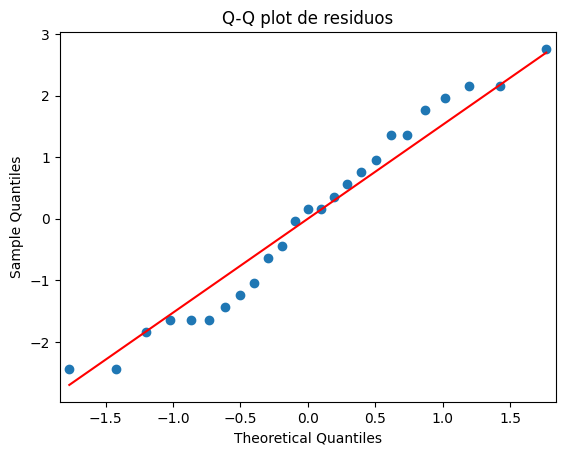

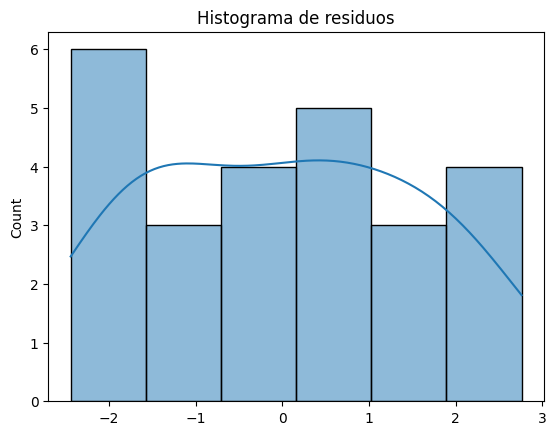

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizadores'] == "A"]['tiempo']
grupo2 = df[df['catalizadores'] == "B"]['tiempo']
grupo3 = df[df['catalizadores'] == "C"]['tiempo']
grupo4 = df[df['catalizadores'] == "D"]['tiempo']
grupo5 = df[df['catalizadores'] == "E"]['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.7643124196676653


Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.2131 -4.8493 -0.7507   True
     A      C      0.4 0.9976 -1.6493  2.4493  False
     A      D     -5.0 0.0061 -7.0493 -2.9507   True
     A      E     -4.8 0.0087 -6.8493 -2.7507   True
     B      C      3.2  0.122  1.1507  5.2493   True
     B      D     -2.2 0.4316 -4.2493 -0.1507   True
     B      E     -2.0 0.5231 -4.0493  0.0493  False
     C      D     -5.4  0.003 -7.4493 -3.3507   True
     C      E     -5.2 0.0043 -7.2493 -3.1507   True
     D      E      0.2 0.9998 -1.8493  2.2493  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

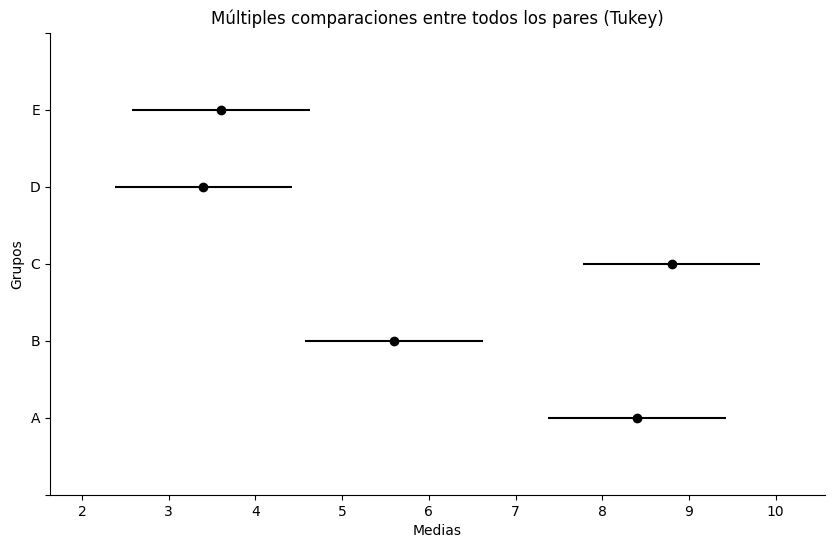

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['catalizadores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

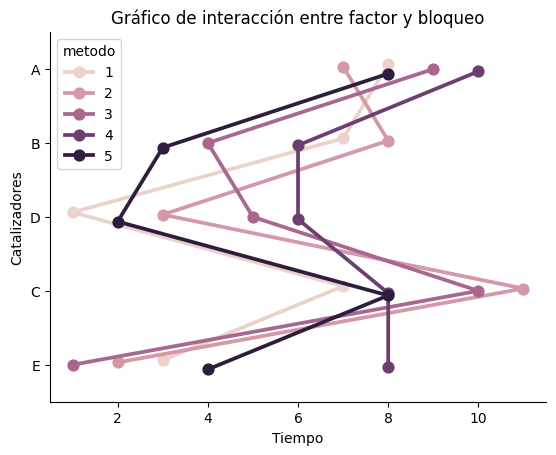

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="tiempo", y="catalizadores", hue="lote", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Tiempo")
plt.ylabel("Catalizadores")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()


a) ¿Se justifica eliminar día?
Sí, porque en el Problema 7 el día no fue significativo.

b) Diseño, modelo e hipótesis
El diseño pasa a ser un diseño en bloques completos al azar, con:
Tratamiento: catalizador.
Bloque: lote.

c) Prueba y conclusiones
Los catalizadores siguen siendo significativos, con valor-p aproximadamente 0.0001.

El lote no es significativo.
d) Comparación del error
El cuadrado medio del error aumenta un poco al eliminar el día, porque la variación del día se incorpora al error.

e) ¿Por qué se obtienen las mismas conclusiones?
Porque el día no aportaba una fuente importante de variabilidad; por eso eliminarlo no cambia la conclusión sobre catalizadores.

## Problema 9
Con respecto a los problemas 7 y 8, además de eliminar el factor día ahora elimine el factor lote, y conteste lo siguiente:

a) ¿Se justifica esta segunda eliminación en ambos problemas?  
b) Después de la doble eliminación, señale el nombre del diseño, el modelo y la(s) hipótesis más adecuada(s) al problema.  
c) Pruebe las hipótesis y obtenga conclusiones.  
d) Compare el cuadro medio del error obtenido con los de los problemas 16 y 17. ¿Qué observa? ¿Cómo lo explica?  
e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y de los dos anteriores?  
f) ¿Cree que esta eliminación hubiese afectado si los factores de bloque hubieran sido significativos?  


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
catalizadores,tiempo
A,8
B,7
D,1
C,7
E,3
C,11
E,2
A,7
D,3
B,8
B,4
A,9
C,10
E,1
D,5
D,6
C,8
E,8
B,6
A,10
E,4
D,2
B,3
A,8
C,8

'''

df = pd.read_csv(StringIO(data))
df

,catalizadores,tiempo
0,A,8
1,B,7
2,D,1
3,C,7
4,E,3
5,C,11
6,E,2
7,A,7
8,D,3
9,B,8


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'tiempo ~ C(catalizadores)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(catalizadores),131.36,4.0,8.251256,0.000423
Residual,79.60,20.0,NaN,NaN


valor-p (Shapiro) = 0.3655789770446113


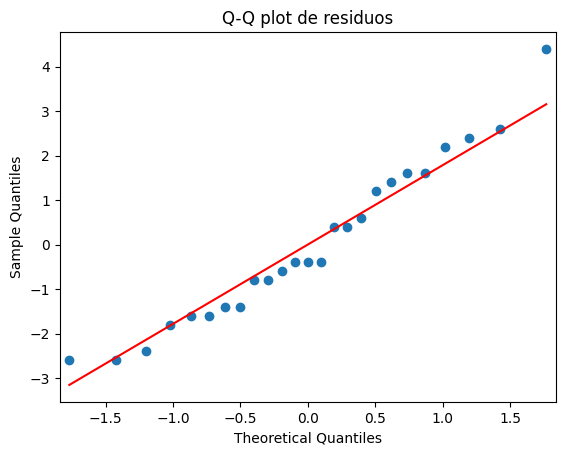

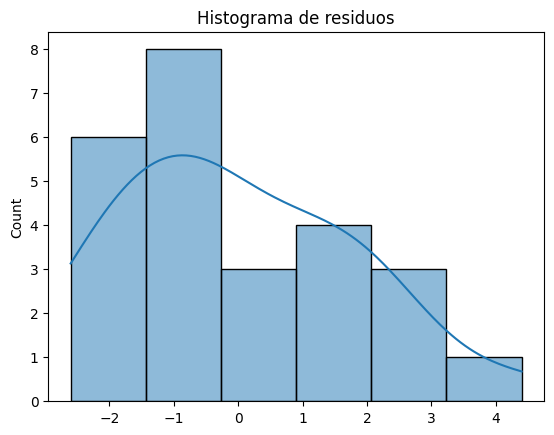

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizadores'] == "A"]['tiempo']
grupo2 = df[df['catalizadores'] == "B"]['tiempo']
grupo3 = df[df['catalizadores'] == "C"]['tiempo']
grupo4 = df[df['catalizadores'] == "D"]['tiempo']
grupo5 = df[df['catalizadores'] == "E"]['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.7643124196676653


Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.2131 -4.8493 -0.7507   True
     A      C      0.4 0.9976 -1.6493  2.4493  False
     A      D     -5.0 0.0061 -7.0493 -2.9507   True
     A      E     -4.8 0.0087 -6.8493 -2.7507   True
     B      C      3.2  0.122  1.1507  5.2493   True
     B      D     -2.2 0.4316 -4.2493 -0.1507   True
     B      E     -2.0 0.5231 -4.0493  0.0493  False
     C      D     -5.4  0.003 -7.4493 -3.3507   True
     C      E     -5.2 0.0043 -7.2493 -3.1507   True
     D      E      0.2 0.9998 -1.8493  2.2493  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

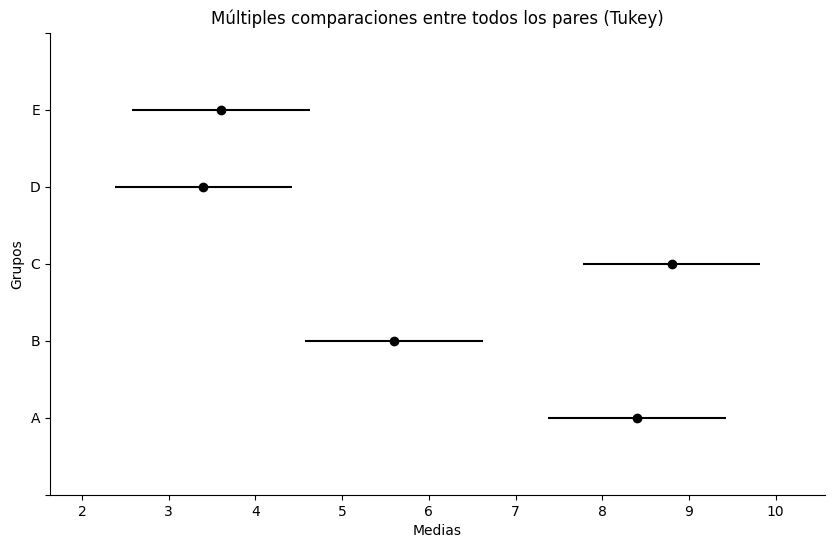

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['catalizadores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

/tmp/ipykernel_388/4249319424.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="metodo")


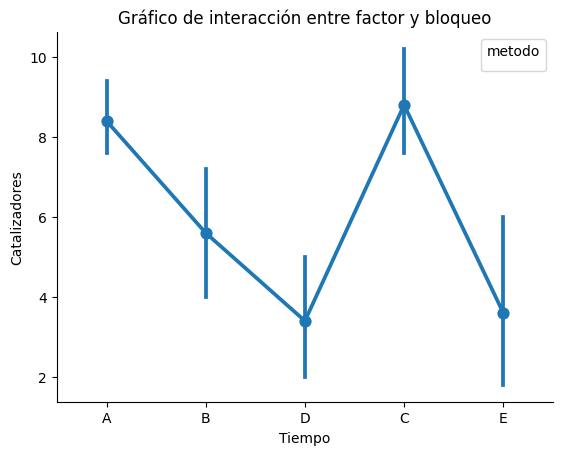

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="catalizadores", y="tiempo", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Tiempo")
plt.ylabel("Catalizadores")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()


c) Conclusiones
Los catalizadores siguen siendo significativos, con valor-p aproximadamente 0.0001.

d) Comparación del error
El error aumenta al quitar los bloques, porque la variabilidad de lote y día pasa al error. Sin embargo, como esos factores no eran significativos, el cambio no altera la conclusión principal.

e) ¿Por qué se mantienen conclusiones?
Porque el efecto de los catalizadores es grande comparado con la variabilidad de lote y día.

f) ¿Qué hubiera pasado si los bloques fueran significativos?
Si lote o día hubieran sido significativos, eliminarlos habría sido incorrecto, porque aumentaría mucho el error y podría ocultar diferencias reales entre tratamientos.


## Problema 10
Se comprueba el peso en gramos de un material de tres proveedores: **A, B y C**, por tres diferentes inspectores: **I, II y III**, utilizando tres diferentes escalas: **1, 2 y 3**. El experimento se lleva a cabo como el siguiente cuadro latino:

| Inspector | Escala 1 | Escala 2 | Escala 3 |
|-----------|----------|----------|----------|
| I         | A = 16   | B = 10   | C = 11   |
| II        | B = 15   | C = 9    | A = 14   |
| III       | C = 13   | A = 11   | B = 13   |

**Preguntas:**<br>
a) ¿Hay diferencias entre los proveedores?  
b) ¿Hay diferencias entre los inspectores y entre las escalas?  
c) Si el peso debe ser 15 g, ¿cuál proveedor es mejor?  
d) Si algún factor de bloque es no significativo, elimínelo y haga el análisis adecuado.  


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
proveedores,inspector,escalas,peso
A,I,1,16
B,I,2,10
C,I,3,11
B,II,1,15
C,II,2,9
A,II,3,14
C,III,1,13
A,III,2,11
B,III,3,13
'''

df = pd.read_csv(StringIO(data))
df

,proveedores,inspector,escalas,peso
0,A,I,1,16
1,B,I,2,10
2,C,I,3,11
3,B,II,1,15
4,C,II,2,9
5,A,II,3,14
6,C,III,1,13
7,A,III,2,11
8,B,III,3,13


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'peso ~ C(proveedores) + C(escalas) + C(inspector)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(proveedores),10.888889,2.0,49.0,0.020000
C(escalas),32.888889,2.0,148.0,0.006711
C(inspector),0.222222,2.0,1.0,0.500000
Residual,0.222222,2.0,NaN,NaN


valor-p (Shapiro) = 0.00015259147070224657


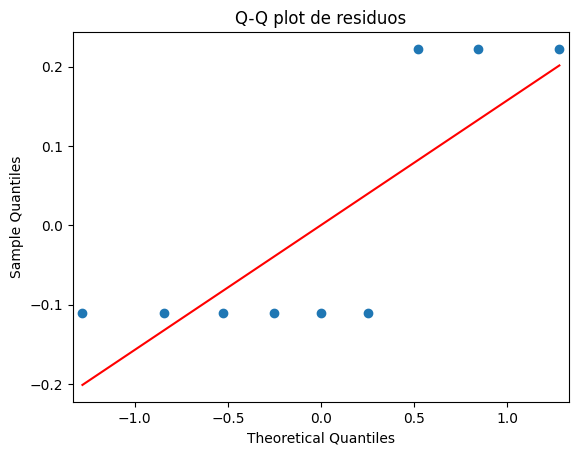

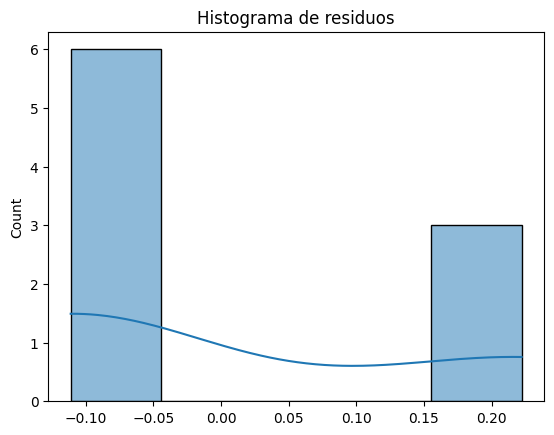

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedores'] == 'A']['peso']
grupo2 = df[df['proveedores'] == 'B']['peso']
grupo3 = df[df['proveedores'] == 'C']['peso']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.946440270473328


Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -1.0 0.8649 -3.2923  1.2923  False
     A      C  -2.6667 0.4051 -4.9589 -0.3744   True
     B      C  -1.6667 0.6793 -3.9589  0.6256  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

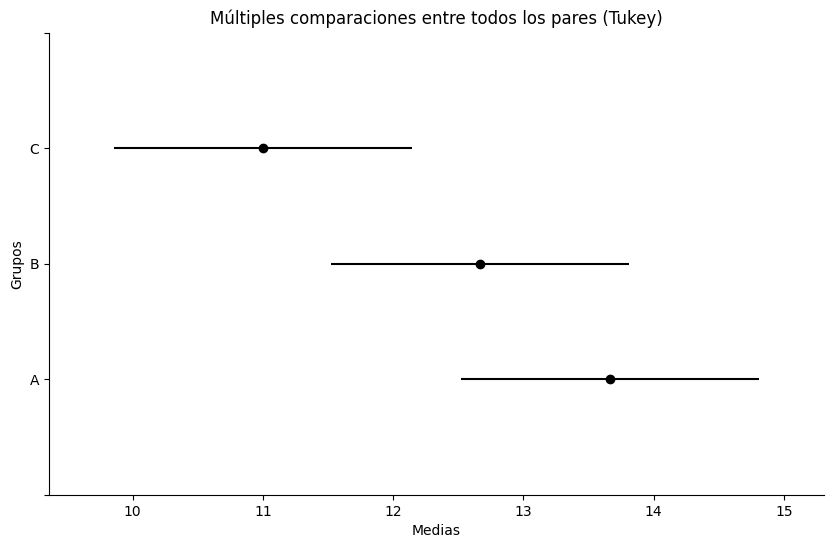

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso'], groups=df['proveedores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

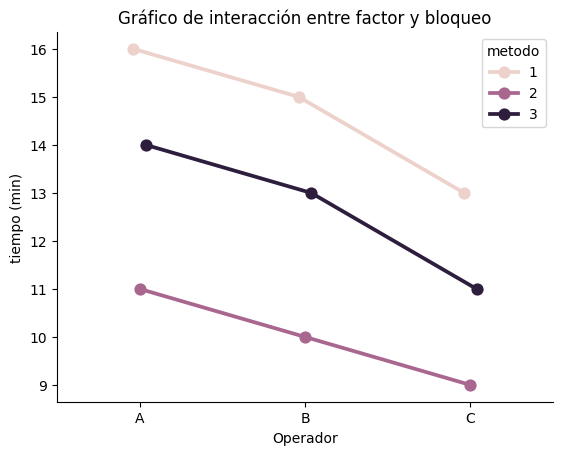

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="proveedores", y="peso", hue="escalas", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

Lambda óptimo: 0.4815596936787171


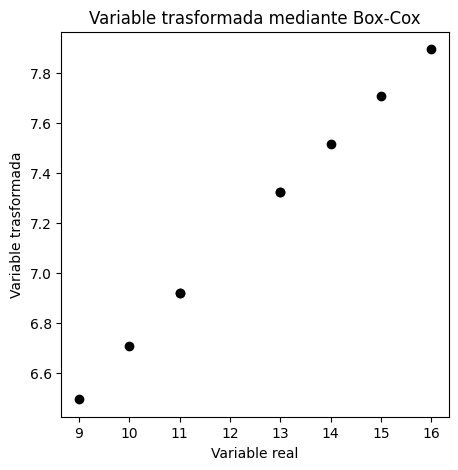

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["peso_boxcox"], lambda_opt = boxcox(df["peso"]+10)
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["peso"], df["peso_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'peso_boxcox ~ C(proveedores) + C(escalas) + C(inspector)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(proveedores),0.432114,2.0,71.943231,0.013709
C(escalas),1.316617,2.0,219.205376,0.004541
C(inspector),0.007190,2.0,1.197055,0.455155
Residual,0.006006,2.0,NaN,NaN


valor-p (Shapiro) = 0.00021681604010336338


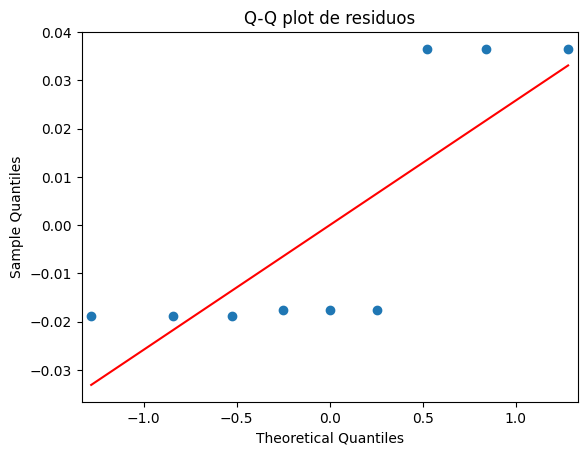

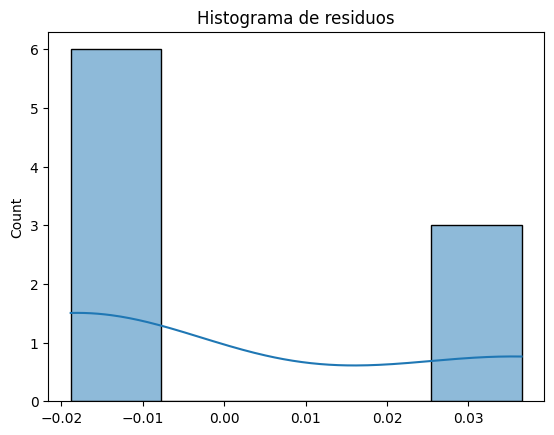

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedores'] == 'A']['peso_boxcox']
grupo2 = df[df['proveedores'] == 'B']['peso_boxcox']
grupo3 = df[df['proveedores'] == 'C']['peso_boxcox']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9655329086803885


Multiple Comparison of Means - Tukey HSD, FWER=0.50
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B  -0.1967 0.8686 -0.6546 0.2612  False
     A      C  -0.5308 0.4072 -0.9887 -0.073   True
     B      C  -0.3341 0.6775  -0.792 0.1237  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

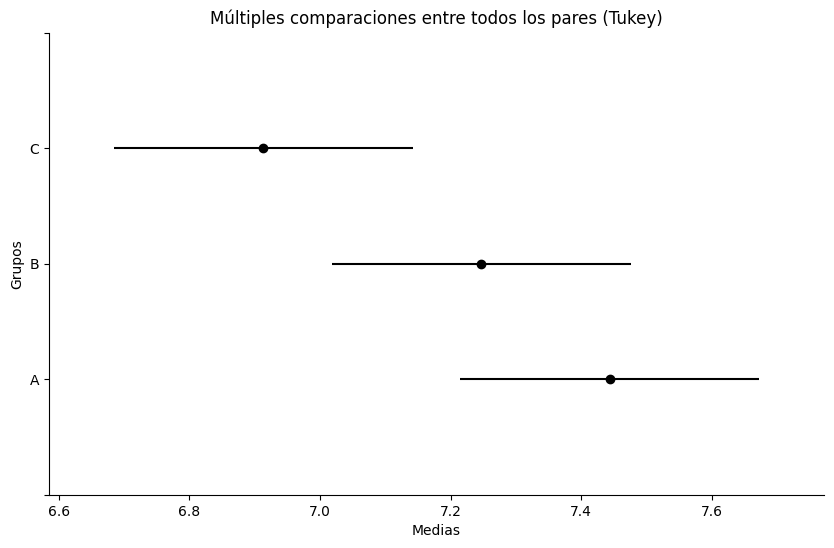

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso_boxcox'], groups=df['proveedores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

a) Diferencias entre proveedores
Sí hay diferencias significativas entre proveedores, valor-p aproximado 0.0200.
Promedios:
A: 13.67
B: 12.67
C: 11.00

b) Diferencias entre inspectores y escalas
Inspectores: no hay diferencia significativa, valor-p = 0.5000.
Escalas: sí hay diferencia significativa, valor-p aproximado 0.0067.

c) Si el peso debe ser 15 g, ¿cuál proveedor es mejor?
El proveedor A es el mejor, porque su promedio, 13.67 g, es el más cercano a 15 g.

d) Eliminar factor no significativo
Se puede eliminar el factor inspector, porque no fue significativo.
Conclusión general: proveedor y escala influyen; inspector no.

## Problema 11
Cuando se comparan varios fertilizantes o diferentes variedades de cierto cultivo, es típico que se deba considerar el gradiente de fertilidad del suelo (factor columna) o los efectos residuales de cultivos previos (factor renglón). Considerando estos factores de bloque, Gomez y Gomez (1984) plantean un experimento en cuadro latino para comparar, en cuanto a rendimiento en toneladas por hectárea, tres variedades de maíz híbrido (**A, B, C**) y una variedad control (**D**). Para ello, se utiliza un campo agrícola cuadrado de 16 hectáreas, dividido en parcelas de una hectárea. Los datos de rendimiento obtenidos en cada parcela se muestran a continuación:

| Ren\Col | 1       | 2       | 3       | 4       |
|---------|---------|---------|---------|---------|
| 1       | 1.640(B)| 1.210(D)| 1.425(C)| 1.345(A)|
| 2       | 1.475(C)| 1.185(A)| 1.400(D)| 1.290(B)|
| 3       | 1.670(A)| 0.710(C)| 1.665(B)| 1.180(D)|
| 4       | 1.565(D)| 1.290(B)| 1.655(A)| 0.660(C)|

**Preguntas y ejercicios:**<br>
a) ¿Existen diferencias en los rendimientos de las diferentes variedades de maíz?  
b) ¿Cuál de los factores de bloque tuvo efectos?  
c) ¿Se habrían detectado las mismas diferencias en los tratamientos con un diseño completamente al azar?  
d) ¿Y con un diseño en bloques completos al azar?  


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
maiz,renglon,columna,rendimiento
B,1,1,1.640
D,1,2,1.210
C,1,3,1.425
A,1,4,1.345
C,2,1,1.475
A,2,2,1.185
D,2,3,1.400
B,2,4,1.290
A,3,1,1.670
C,3,2,0.710
B,3,3,1.665
D,3,4,1.180
D,4,1,1.565
B,4,2,1.290
A,4,3,1.655
C,4,4,0.660
'''

df = pd.read_csv(StringIO(data))
df

,maiz,renglon,columna,rendimiento
0,B,1,1,1.640
1,D,1,2,1.210
2,C,1,3,1.425
3,A,1,4,1.345
4,C,2,1,1.475
5,A,2,2,1.185
6,D,2,3,1.400
7,B,2,4,1.290
8,A,3,1,1.670
9,C,3,2,0.710


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'rendimiento ~ C(maiz) + C(renglon) + C(columna)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(maiz),0.426842,3.0,6.587865,0.025092
C(renglon),0.030155,3.0,0.465406,0.716972
C(columna),0.827342,3.0,12.769166,0.005148
Residual,0.129584,6.0,NaN,NaN


valor-p (Shapiro) = 0.20260853040992888


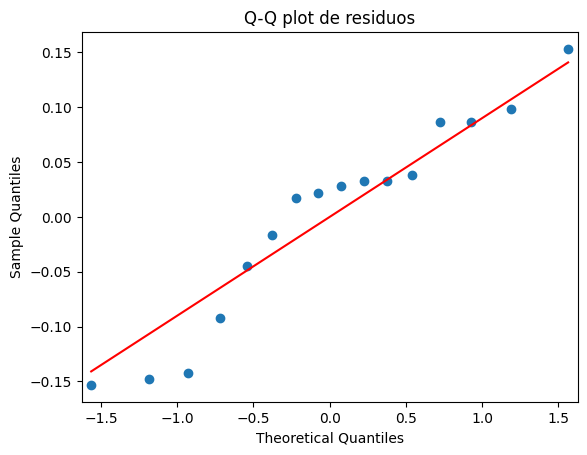

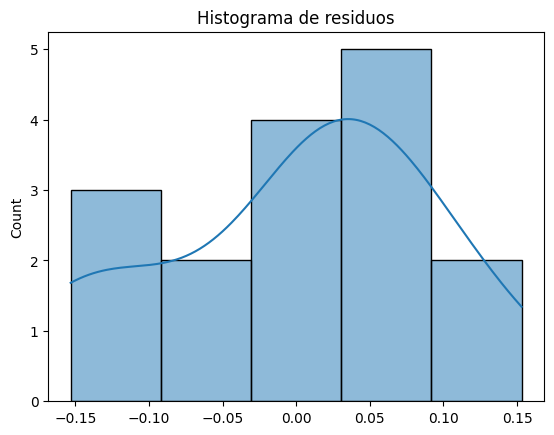

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['maiz'] == 'A']['rendimiento']
grupo2 = df[df['maiz'] == 'B']['rendimiento']
grupo3 = df[df['maiz'] == 'C']['rendimiento']
grupo4 = df[df['maiz'] == 'D']['rendimiento']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.00035260549065253474


Multiple Comparison of Means - Tukey HSD, FWER=0.50 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   0.0075    1.0 -0.2846  0.2996  False
     A      C  -0.3962 0.2578 -0.6883 -0.1042   True
     A      D   -0.125 0.9249 -0.4171  0.1671  False
     B      C  -0.4037 0.2444 -0.6958 -0.1117   True
     B      D  -0.1325 0.9124 -0.4246  0.1596  False
     C      D   0.2712 0.5583 -0.0208  0.5633  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

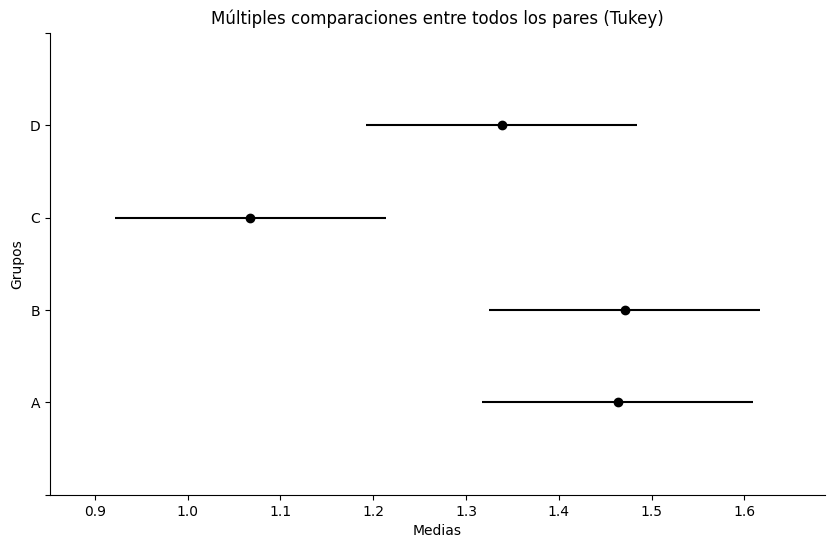

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['rendimiento'], groups=df['maiz'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

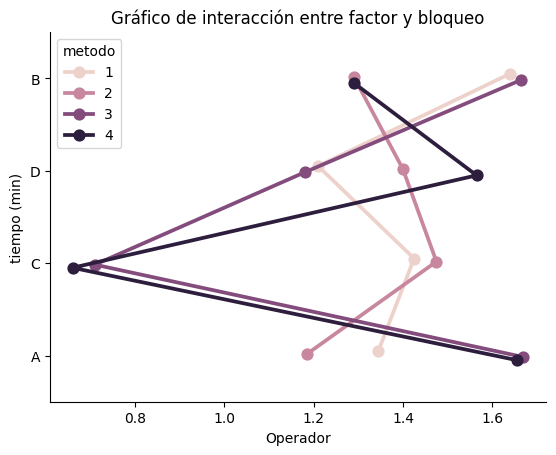

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="rendimiento", y="maiz", hue="renglon", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

Lambda óptimo: 17.89134986900383


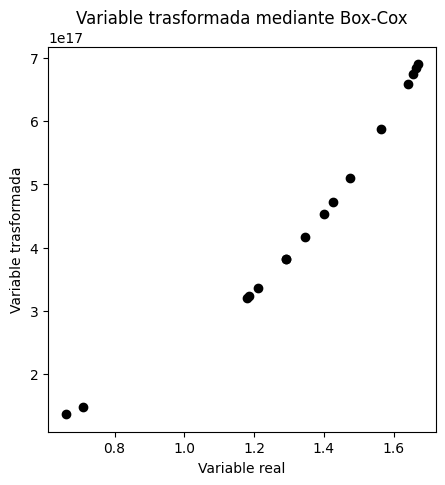

In [ ]:
# Dayana Nathali Hernandez Hernandez
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["rendimiento_boxcox"], lambda_opt = boxcox(df["rendimiento"]+10)
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["rendimiento"], df["rendimiento_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'rendimiento_boxcox ~ C(maiz) + C(renglon) + C(columna)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(maiz),1.199490e+35,3.0,13.591619,0.004389
C(renglon),6.574489e+33,3.0,0.744966,0.563367
C(columna),3.305922e+35,3.0,37.459941,0.000279
Residual,1.765044e+34,6.0,NaN,NaN


valor-p (Shapiro) = 0.861952934407816


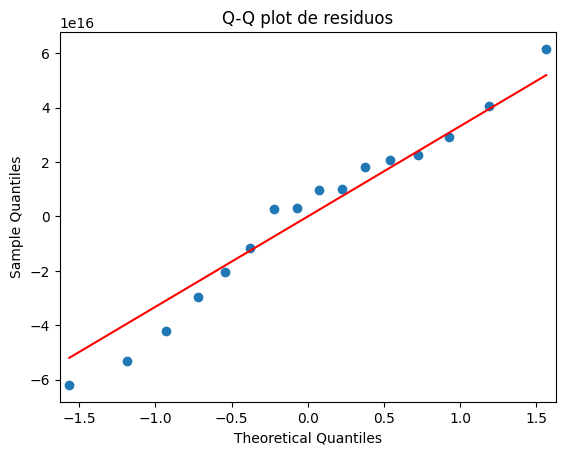

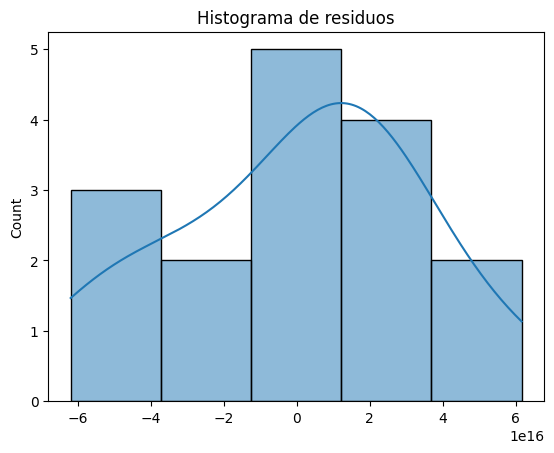

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['maiz'] == 'A']['rendimiento_boxcox']
grupo2 = df[df['maiz'] == 'B']['rendimiento_boxcox']
grupo3 = df[df['maiz'] == 'C']['rendimiento_boxcox']
grupo4 = df[df['maiz'] == 'D']['rendimiento_boxcox']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.09249897668198215


                        Multiple Comparison of Means - Tukey HSD, FWER=0.50                        
group1 group2         meandiff        p-adj           lower                   upper          reject
---------------------------------------------------------------------------------------------------
     A      B       863116750394816.0    1.0 -1.7426062184802662e+17  1.7598685534881626e+17  False
     A      C -2.0888880418615782e+17 0.3568 -3.8401254278457926e+17 -3.3765065587736384e+16   True
     A      D -1.0152617368045562e+17 0.8369 -2.7664991227887706e+17   7.359756491796582e+16  False
     B      C -2.0975192093655264e+17 0.3535  -3.848756595349741e+17 -3.4628182338131196e+16   True
     B      D -1.0238929043085043e+17 0.8336 -2.7751302902927187e+17     7.2734448167571e+16  False
     C      D   1.073626305057022e+17 0.8136  -6.776110809271923e+16  2.8248636910412365e+17  False
---------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

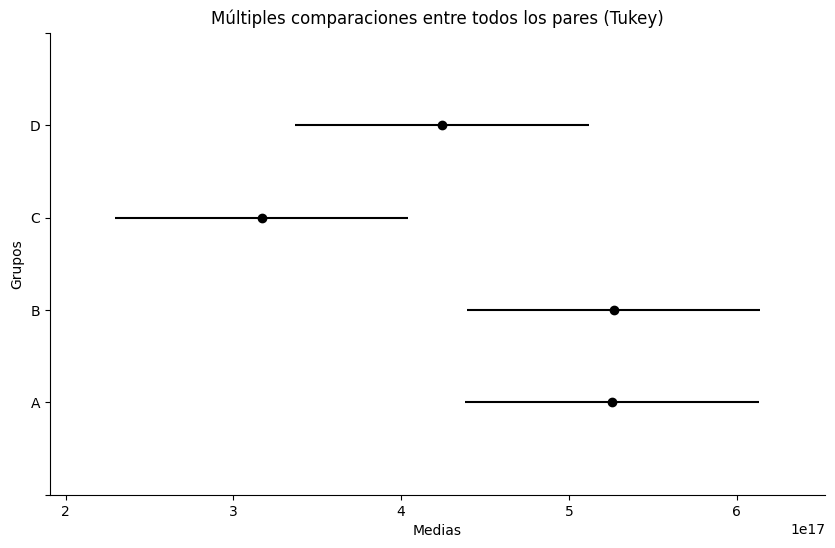

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['rendimiento_boxcox'], groups=df['maiz'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

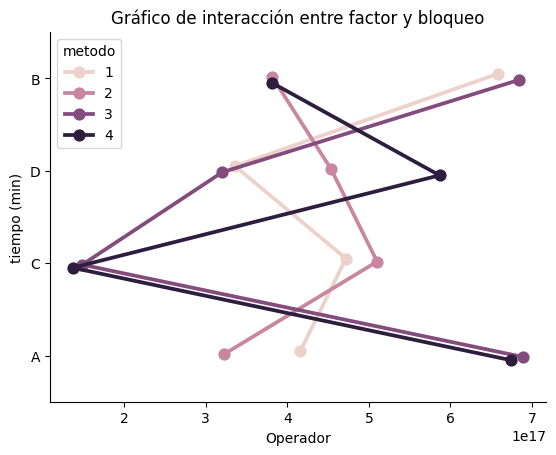

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="rendimiento_boxcox", y="maiz", hue="renglon", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Operador")
plt.ylabel("tiempo (min)")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()


a) Diferencias entre variedades
Sí existen diferencias significativas entre variedades de maíz, valor-p aproximado 0.0251.
Promedios:
A: 1.464
B: 1.471
C: 1.068
D: 1.339
Conclusión: la variedad B tuvo el mayor rendimiento promedio, seguida muy de cerca por A.

b) Factor de bloque con efecto
El factor columna fue significativo, valor-p aproximado 0.0051.
El factor renglón no fue significativo.

c) ¿Se detectaría lo mismo con DCA?
No. Con diseño completamente al azar, el efecto de variedades no sería significativo, porque el error sería mayor.

d) ¿Y con DBCA?
Si sólo se bloqueara por renglón, tampoco se detectaría diferencia significativa. El bloque importante fue columna.
Conclusión general: el cuadro latino fue importante porque permitió controlar la variación por columnas.

## Problema 12
Se quieren comparar tres dietas (**A, B, C**) a base de proteínas de origen vegetal utilizando 18 ratas de laboratorio de una misma camada. Primero se observa por un tiempo el apetito para formar tres grupos de seis ratas, según su voracidad; y cada uno de estos grupos se clasifica a su vez en tres grupos de dos ratas, de acuerdo a su peso inicial. Se plantea un experimento donde la variable de respuesta es el peso en gramos ganado por las ratas después de cierto periodo, con los siguientes resultados:

| Apetito/peso inicial | A1        | A2        | A3        |
|-----------------------|-----------|-----------|-----------|
| P1                   | 67 (C)    | 105 (A)   | 95 (B)    |
|                       | 72        | 112       | 86        |
| P2                   | 85 (A)    | 75 (B)    | 88 (C)    |
|                       | 98        | 67        | 110       |
| P3                   | 66 (B)    | 68 (C)    | 108 (A)   |
|                       | 47        | 91        | 120       |

### Preguntas:
a) Analice los datos. ¿Cuáles de los factores influyen en el peso ganado por las ratas?  
b) ¿Cuál dieta es mejor?  
c) ¿Alguno de los factores de bloque puede ser ignorado? Argumente su respuesta.  
d) Si ese fuera el caso, analice de nuevo el experimento y saque conclusiones.  
e) Verifique los supuestos del modelo.  


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
dietas,apetito,pesoinicial,gramos
C,P1,A1,67
C,P1,A1,72
A,P1,A2,105
A,P1,A2,112
B,P1,A3,95
B,P1,A3,86
A,P2,A1,85
A,P2,A1,98
B,P2,A2,75
B,P2,A2,67
C,P2,A3,88
C,P2,A3,110
B,P3,A1,66
B,P3,A1,47
C,P3,A2,68
C,P3,A2,91
A,P3,A3,108
A,P3,A3,120
'''

df = pd.read_csv(StringIO(data))
df

,dietas,apetito,pesoinicial,gramos
0,C,P1,A1,67
1,C,P1,A1,72
2,A,P1,A2,105
3,A,P1,A2,112
4,B,P1,A3,95
5,B,P1,A3,86
6,A,P2,A1,85
7,A,P2,A1,98
8,B,P2,A2,75
9,B,P2,A2,67


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'gramos ~ C(dietas) + C(pesoinicial) + C(apetito)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(dietas),3216.000000,2.0,17.951286,0.000344
C(pesoinicial),2466.333333,2.0,13.766746,0.001013
C(apetito),116.333333,2.0,0.649357,0.541292
Residual,985.333333,11.0,NaN,NaN


valor-p (Shapiro) = 0.26073461350664606


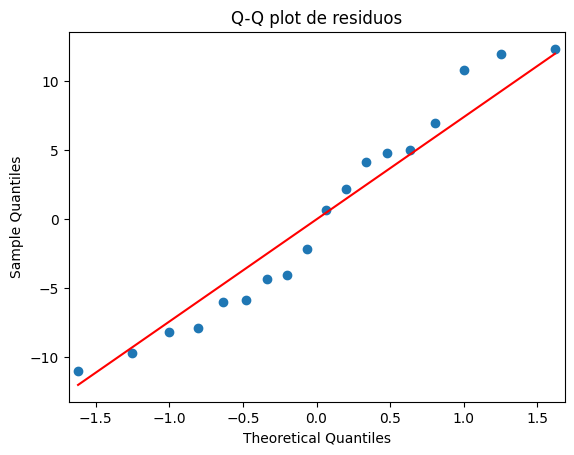

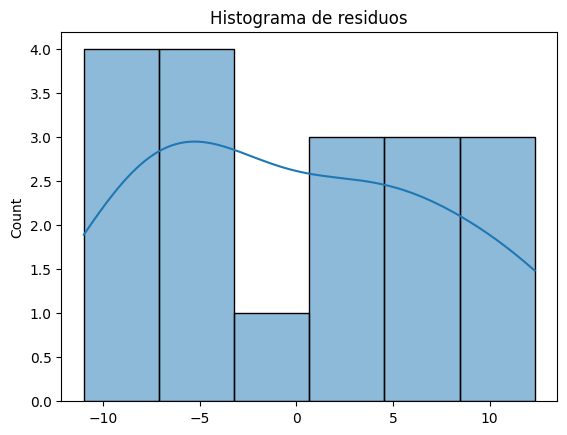

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['dietas'] == 'A']['gramos']
grupo2 = df[df['dietas'] == 'B']['gramos']
grupo3 = df[df['dietas'] == 'C']['gramos']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.5795758016998872


 Multiple Comparison of Means - Tukey HSD, FWER=0.50  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B    -32.0 0.0071 -42.2339 -21.7661   True
     A      C    -22.0 0.0634 -32.2339 -11.7661   True
     B      C     10.0 0.5152  -0.2339  20.2339  False
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

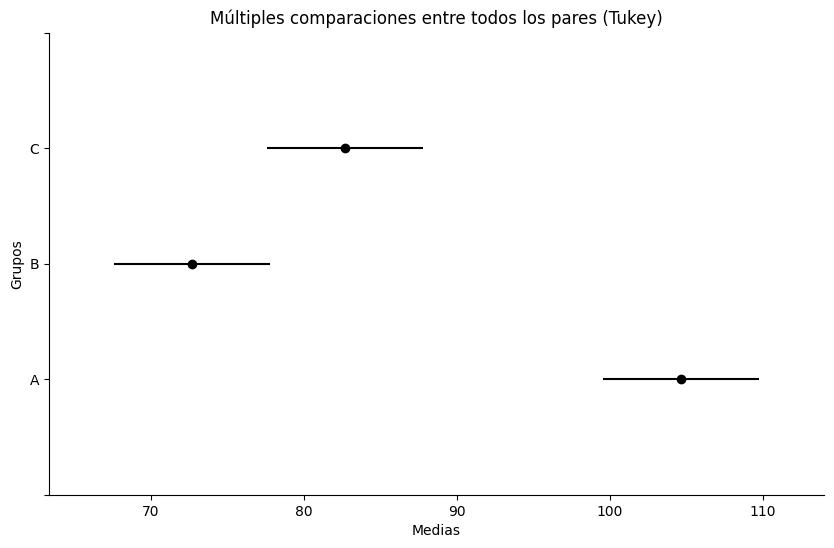

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['gramos'], groups=df['dietas'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

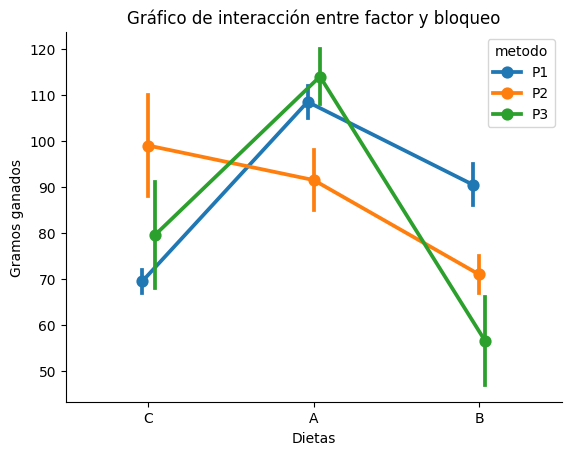

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="dietas", y="gramos", hue="apetito", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Dietas")
plt.ylabel("Gramos ganados")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()


a) Factores que influyen
Influyen significativamente:
Dieta: valor-p aproximado 0.0003.
Peso inicial: valor-p aproximado 0.0010.
No influye significativamente:
Apetito: valor-p aproximado 0.5413.

b) Mejor dieta
Promedios:
A: 104.67 g
B: 72.67 g
C: 82.67 g
La mejor dieta es A, porque produjo la mayor ganancia de peso.
c) ¿Algún bloque puede ignorarse?
Sí, el bloque apetito puede ignorarse porque no fue significativo.

d) Nuevo análisis
Al eliminar apetito, deberían mantenerse como importantes la dieta y el peso inicial.

e) Supuestos
Normalidad e igualdad de varianzas son aceptables.
Conclusión general: la dieta A es la mejor y el peso inicial sí influye en la ganancia.

## Problema 13
Una compañía distribuidora ubicada en los suburbios está interesada en estudiar la diferencia en costos (tiempo y gasolina) entre las cuatro rutas (**A, B, C, D**) que llevan a la zona comercial, más importante para ellos, en el otro extremo de la ciudad. Deciden correr un experimento en cuadro grecolatino controlando los factores de bloque **chofer**, marca de vehículo (**α, β, χ, δ**) y día de la semana. El experimento se repite en dos semanas diferentes, en las cuales no hay días festivos ni quincenas. Los costos observados en pesos se muestran en la siguiente tabla:

| Chofer/día | Lunes       | Martes      | Miércoles   | Jueves      |
|------------|-------------|-------------|-------------|-------------|
| Carlos     | 825(D, α)   | 585(C, χ)   | 550(B, β)   | 580(A, δ)   |
|            | 750         | 610         | 580         | 650         |
| Enrique    | 650(A, χ)   | 540(B, α)   | 580(C, χ)   | 850(D, β)   |
|            | 725         | 560         | 635         | 770         |
| Genaro     | 700(C, β)   | 650(D, δ)   | 635(A, α)   | 450(B, χ)   |
|            | 675         | 740         | 540         | 550         |
| Luis       | 475(B, δ)   | 560(A, β)   | 650(D, α)   | 670(C, α)   |
|            | 480         | 615         | 725         | 730         |

### Preguntas:
a) Haga el análisis de varianza de este experimento.  
b) Realice las pruebas de comparaciones múltiples para los factores significativos.  
c) Represente los tratamientos y factores de bloque usando gráficas de medias y diagramas de dispersión.  
d) ¿Cuál es la mejor ruta? ¿Cuál es la peor?  
e) ¿Hay diferencias significativas entre los choferes? ¿Y entre el tipo o marca de unidad?  
f) ¿Cuáles factores de bloque valió la pena tomar en cuenta en el experimento?  
g) ¿Por qué se evitaron días festivos y quincenas en el experimento? ¿Cuáles otros aspectos se tenían que tomar en cuenta?  
h) Verifique los supuestos del modelo.  


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
ruta,chofer,marca,dia,costo
D,Carlos,α,Lunes,825
D,Carlos,α,Lunes,750
C,Carlos,χ,Martes,585
C,Carlos,χ,Martes,610
B,Carlos,β,Miercoles,550
B,Carlos,β,Miercoles,580
A,Carlos,δ,Jueves,580
A,Carlos,δ,Jueves,650
A,Enrique,χ,Lunes,650
A,Enrique,χ,Lunes,725
B,Enrique,α,Martes,540
B,Enrique,α,Martes,560
D,Enrique,β,Miercoles,580
D,Enrique,β,Miercoles,635
C,Enrique,χ,Jueves,850
C,Enrique,χ,Jueves,770
C,Genaro,β,Lunes,700
C,Genaro,β,Lunes,675
D,Genaro,δ,Martes,650
D,Genaro,δ,Martes,740
A,Genaro,α,Miercoles,635
A,Genaro,α,Miercoles,540
B,Genaro,χ,Jueves,450
B,Genaro,χ,Jueves,550
B,Luis,δ,Lunes,475
B,Luis,δ,Lunes,480
A,Luis,β,Martes,560
A,Luis,β,Martes,615
D,Luis,α,Miercoles,650
D,Luis,α,Miercoles,725
C,Luis,α,Jueves,670
C,Luis,α,Jueves,730
'''

df = pd.read_csv(StringIO(data))
df

,ruta,chofer,marca,dia,costo
0,D,Carlos,α,Lunes,825
1,D,Carlos,α,Lunes,750
2,C,Carlos,χ,Martes,585
3,C,Carlos,χ,Martes,610
4,B,Carlos,β,Miercoles,550
5,B,Carlos,β,Miercoles,580
6,A,Carlos,δ,Jueves,580
7,A,Carlos,δ,Jueves,650
8,A,Enrique,χ,Lunes,650
9,A,Enrique,χ,Lunes,725


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Crear el modelo ANOVA para un cuadro latino
modelo = ols(f'costo ~ C(ruta) + C(chofer) + C(marca) + C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(ruta),148258.649834,3.0,10.299462,0.000304
C(chofer),11995.018530,3.0,0.833289,0.492074
C(marca),10528.273665,3.0,0.731394,0.545978
C(dia),22328.024571,3.0,1.551118,0.233995
Residual,91167.038835,19.0,NaN,NaN


valor-p (Shapiro) = 0.26073461350664606


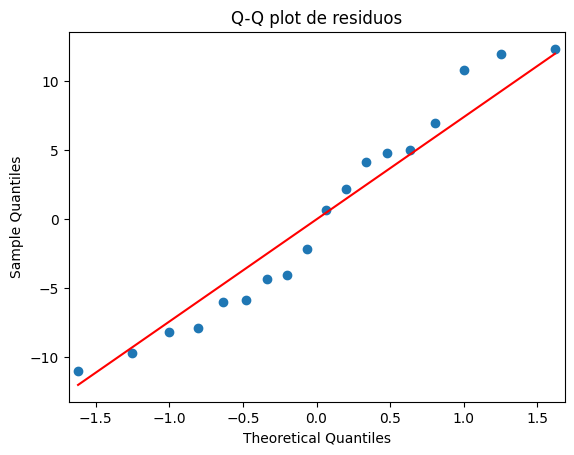

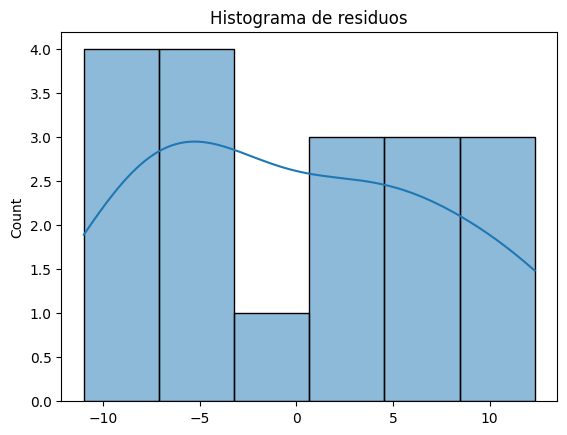

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['ruta'] == 'A']['costo']
grupo2 = df[df['ruta'] == 'B']['costo']
grupo3 = df[df['ruta'] == 'C']['costo']
grupo4 = df[df['ruta'] == 'D']['costo']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.43018358516033894


  Multiple Comparison of Means - Tukey HSD, FWER=0.50  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B   -96.25  0.046 -145.4939 -47.0061   True
     A      C   79.375 0.1263   30.1311 128.6189   True
     A      D     75.0 0.1602   25.7561 124.2439   True
     B      C  175.625 0.0001  126.3811 224.8689   True
     B      D   171.25 0.0002  122.0061 220.4939   True
     C      D   -4.375 0.9993  -53.6189  44.8689  False
-------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

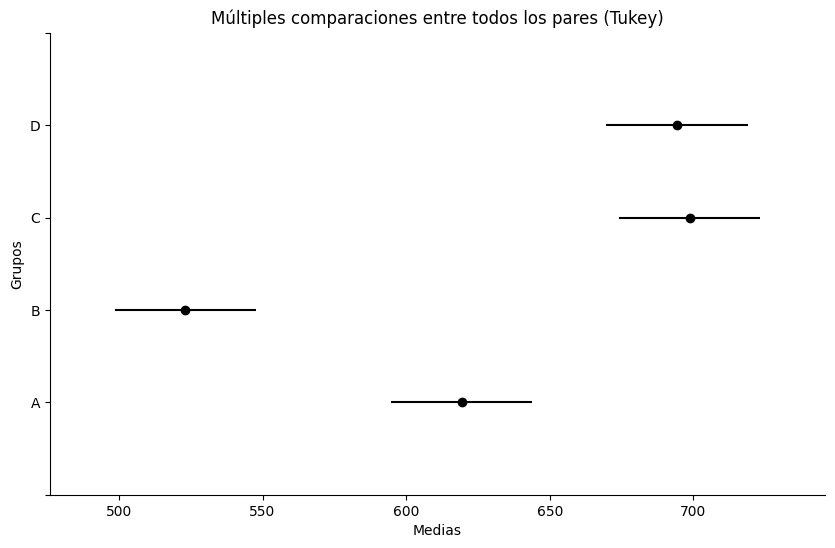

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['costo'], groups=df['ruta'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

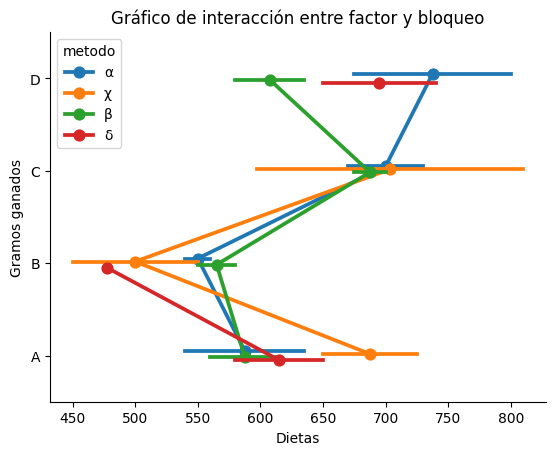

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="costo", y="ruta", hue="marca", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Dietas")
plt.ylabel("Gramos ganados")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()


a) ANOVA
El factor significativo fue la ruta, con valor-p aproximado 0.0003.
No fueron significativos:
Chofer.
Marca del vehículo.
Día.

b) Comparaciones múltiples
Las diferencias importantes fueron:
Ruta B menor que C.
Ruta B menor que D.
Ruta B también fue menor que A.

c) Gráficas
Las gráficas de medias mostrarían a la ruta B con menor costo promedio y a C y D con los mayores costos.

d) Mejor y peor ruta
Promedios:
A: 619.38
B: 523.13
C: 698.75
D: 694.38
La mejor ruta es B, porque tiene menor costo promedio.
La peor ruta es C, ligeramente mayor que D.

e) Diferencias entre choferes y marcas
No hay diferencias significativas entre choferes ni entre marcas.

f) Bloques que valió la pena considerar
Aunque no fueron significativos, se consideraron para controlar posibles fuentes de variación. Estadísticamente, ninguno de esos bloques fue significativo.

g) Días festivos y quincenas
Se evitaron porque pueden alterar el tráfico, el consumo de gasolina y el tiempo de traslado.
Otros aspectos a cuidar:
Horario de salida.
Clima.
Obras viales.
Tráfico.
Estado del vehículo.

h) Supuestos
Los residuos son aceptables; no se observan problemas fuertes de normalidad o varianza.

## Problema 14
23. Un investigador está interesado en el efecto del porcentaje de lisina y del porcentaje de proteína en la producción de vacas lecheras. Se consideran siete niveles en cada factor:

- **% de lisina**: 0.0 (**A**), 0.1 (**B**), 0.2 (**C**), 0.3 (**D**), 0.4 (**E**), 0.5 (**F**), 0.6 (**G**).  
- **% de proteína**: 2 (**α**), 4 (**β**), 6 (**χ**), 8 (**δ**), 10 (**ε**), 12 (**φ**), 14 (**γ**).  

Para el estudio, se seleccionaron siete vacas al azar, a las cuales se les da un seguimiento de siete periodos de tres meses. Los datos en galones de leche fueron los siguientes:

| Vaca/periodo | 1       | 2       | 3       | 4       | 5       | 6       | 7       |
|--------------|---------|---------|---------|---------|---------|---------|---------|
| 1            | 304 (Aα)| 436 (Bε)| 350 (Cβ)| 504 (Dφ)| 417 (Eχ)| 519 (Fγ)| 432 (Gδ)|
| 2            | 381 (Bβ)| 505 (Cφ)| 425 (Dχ)| 564 (Eγ)| 487 (Fα)| 536 (Gε)| 483 (Aχ)|
| 3            | 432 (Cχ)| 566 (Dγ)| 479 (Eε)| 357 (Fα)| 466 (Gβ)| 465 (Aφ)| 507 (Bγ)|
| 4            | 442 (Dδ)| 372 (Eχ)| 536 (Fε)| 366 (Gβ)| 495 (Aχ)| 425 (Bφ)| 507 (Cγ)|
| 5            | 496 (Eε)| 449 (Fβ)| 493 (Gφ)| 345 (Aχ)| 509 (Bγ)| 481 (Cδ)| 380 (Dα)|
| 6            | 534 (Fφ)| 421 (Gχ)| 352 (Aγ)| 427 (Bδ)| 346 (Cχ)| 478 (Dε)| 397 (Eβ)|
| 7            | 543 (Gγ)| 386 (Aδ)| 435 (Bα)| 485 (Cε)| 406 (Dφ)| 554 (Eφ)| 410 (Fχ)|

### Preguntas y ejercicios:
a) Analice este experimento. ¿Qué factores tienen efecto en la producción de leche?  
b) Interprete los resultados usando gráficos de medias.  
c) ¿Cómo puede explicar la falta de efectos en vacas y periodo?  
d) ¿Qué porcentajes de lisina y proteína dan los mejores resultados?  
e) Verifique los supuestos del modelo.  


In [ ]:
#Dayana Nathali Hernandez Hernandez
import pandas as pd
from io import StringIO

data = '''
porcentaje,vaca,periodo,lisina,proteina,leche
Aα,1,1,0.0,2,304
Bε,1,2,0.1,4,436
Cβ,1,3,0.2,2,350
Dφ,1,4,0.3,12,504
Eχ,1,5,0.4,8,417
Fγ,1,6,0.5,14,519
Gδ,1,7,0.6,10,432
Bβ,2,1,0.1,2,381
Cφ,2,2,0.2,12,505
Dχ,2,3,0.3,8,425
Eγ,2,4,0.4,14,564
Fα,2,5,0.5,2,487
Gε,2,6,0.6,4,536
Aχ,2,7,0.0,8,483
Cχ,3,1,0.2,8,432
Dγ,3,2,0.3,14,566
Eφ,3,3,0.4,12,479
Fε,3,4,0.5,10,357
Gβ,3,5,0.6,2,466
Aφ,3,6,0.0,12,465
Bγ,3,7,0.1,14,507
Dδ,4,1,0.3,10,442
Eχ,4,2,0.4,8,372
Fε,4,3,0.5,12,536
Gφ,4,4,0.6,14,366
Aγ,4,5,0.0,14,495
Bφ,4,6,0.1,12,425
Cγ,4,7,0.2,14,507
Eε,5,1,0.4,10,496
Fβ,5,2,0.5,2,449
Gφ,5,3,0.6,14,493
Aχ,5,4,0.0,8,345
Bγ,5,5,0.1,14,509
Cε,5,6,0.2,10,481
Dα,5,7,0.3,2,380
Fφ,6,1,0.5,12,534
Gγ,6,2,0.6,14,421
Aγ,6,3,0.0,14,352
Bδ,6,4,0.1,10,427
Cχ,6,5,0.2,8,346
Dε,6,6,0.3,4,478
Eβ,6,7,0.4,2,397
Gγ,7,1,0.6,14,543
Aδ,7,2,0.0,10,386
Bα,7,3,0.1,2,435
Cε,7,4,0.2,10,485
Dρ,7,5,0.3,14,406
Eφ,7,6,0.4,12,554
Fχ,7,7,0.5,8,410
'''

df = pd.read_csv(StringIO(data))
df

,porcentaje,vaca,periodo,lisina,proteina,leche
0,Aα,1,1,0.0,2,304
1,Bε,1,2,0.1,4,436
2,Cβ,1,3,0.2,2,350
3,Dφ,1,4,0.3,12,504
4,Eχ,1,5,0.4,8,417
5,Fγ,1,6,0.5,14,519
6,Gδ,1,7,0.6,10,432
7,Bβ,2,1,0.1,2,381
8,Cφ,2,2,0.2,12,505
9,Dχ,2,3,0.3,8,425


In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Crear el modelo ANOVA para un cuadro latino
modelo = ols(f'leche ~ C(lisina) + C(vaca) + C(periodo) + C(proteina)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(lisina),19566.003960,6.0,1.028323,0.430329
C(vaca),32126.329678,6.0,1.688452,0.165353
C(periodo),8956.214201,6.0,0.470708,0.823423
C(proteina),71955.292399,5.0,4.538073,0.004421
Residual,79279.564744,25.0,NaN,NaN


valor-p (Shapiro) = 0.26073461350664606


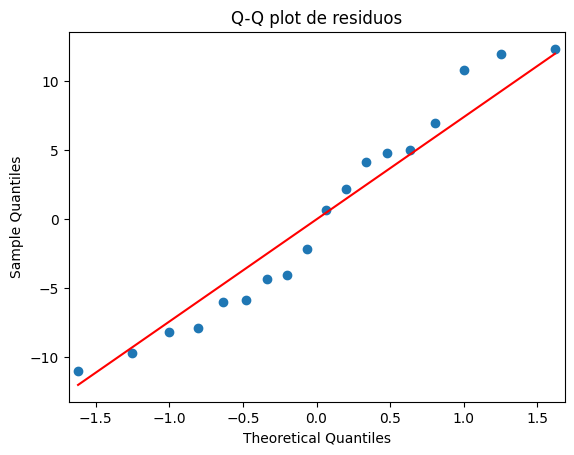

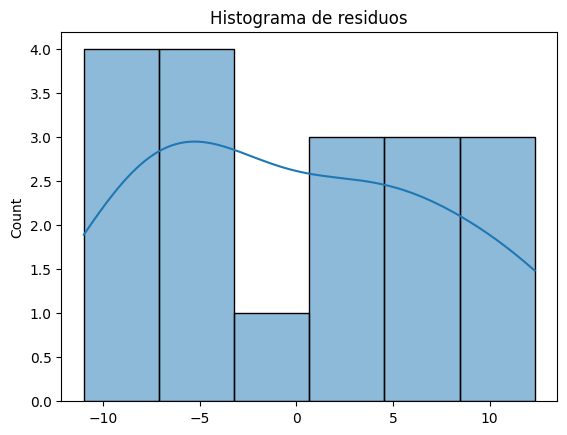

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#Dayana Nathali Hernandez Hernandez
from scipy.stats import levene
# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['vaca'] == 1]['leche']
grupo2 = df[df['vaca'] == 2]['leche']
grupo3 = df[df['vaca'] == 3]['leche']
grupo4 = df[df['vaca'] == 4]['leche']
grupo5 = df[df['vaca'] == 5]['leche']
grupo6 = df[df['vaca'] == 6]['leche']
grupo7 = df[df['vaca'] == 7]['leche']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5, grupo6, grupo7)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9967707433248075


  Multiple Comparison of Means - Tukey HSD, FWER=0.50  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2  59.8571 0.6415   -7.9306 127.6449  False
     1      3  44.2857 0.8773   -23.502 112.0735  False
     1      4  25.8571 0.9906  -41.9306  93.6449  False
     1      5  27.2857 0.9875   -40.502  95.0735  False
     1      6     -1.0    1.0  -68.7877  66.7877  False
     1      7  36.7143  0.946  -31.0735  104.502  False
     2      3 -15.5714 0.9994  -83.3592  52.2163  False
     2      4    -34.0 0.9624 -101.7877  33.7877  False
     2      5 -32.5714 0.9695 -100.3592  35.2163  False
     2      6 -60.8571 0.6238 -128.6449   6.9306  False
     2      7 -23.1429 0.9948  -90.9306  44.6449  False
     3      4 -18.4286 0.9985  -86.2163  49.3592  False
     3      5    -17.0 0.9991  -84.7877  50.7877  False
     3      6 -45.2857 0.8657 -113.0735   22.502  False
     3      7  -7.5714    1.0  -75.3592  60.2163

Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

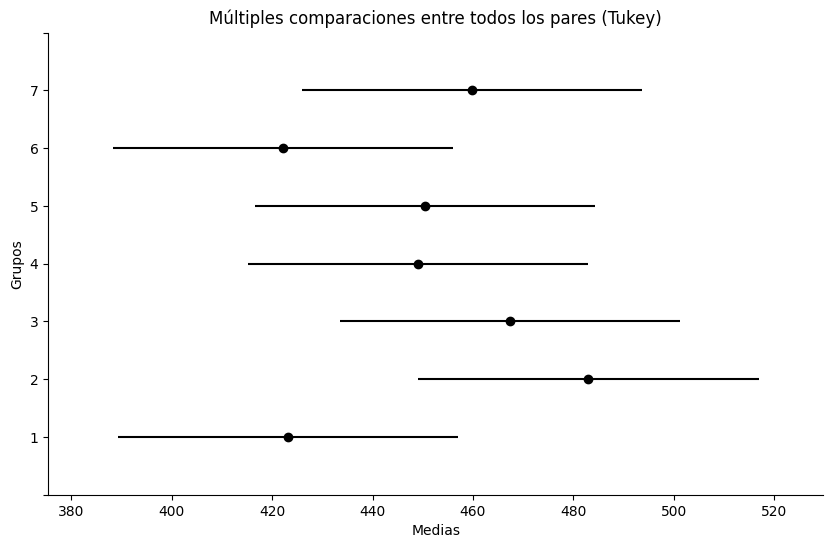

In [ ]:
#Dayana Nathali Hernandez Hernandez
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.50

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['leche'], groups=df['vaca'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

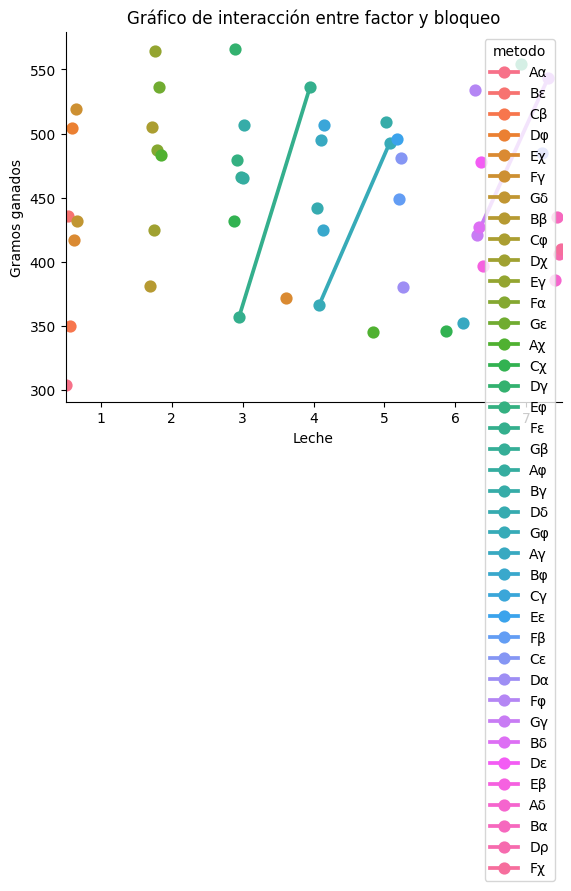

In [ ]:
#Dayana Nathali Hernandez Hernandez
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de interacción
sns.pointplot(x="vaca", y="leche", hue="porcentaje", data=df, dodge=True)
plt.title(f"Gráfico de interacción entre factor y bloqueo")
plt.xlabel("Leche")
plt.ylabel("Gramos ganados")
plt.legend(title="metodo")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.show()

#Dayana Hernandez Hernandez Hernandez

a) Factores con efecto
El factor significativo fue el porcentaje de proteína, con valor-p aproximado 0.0036.
No fueron significativos:
Porcentaje de lisina.
Vaca.
Periodo.

b) Interpretación con medias
Promedios de proteína:
2%: 392.6
4%: 401.5
6%: 414.6
8%: 433.6
10%: 492.3
12%: 497.1
14%: 497.0
La producción aumenta claramente cuando el porcentaje de proteína llega a 10%, 12% y 14%.

c) Falta de efecto en vacas y periodo
Puede explicarse porque el diseño logró controlar bien esas fuentes de variación, o porque las vacas y periodos fueron relativamente homogéneos.

d) Mejor combinación
La lisina no fue significativa, pero el mayor promedio de lisina fue con 0.5%.
Para proteína, los mejores niveles fueron 12% y 14%, muy similares.
Conclusión práctica: una combinación recomendable sería alrededor de 0.5% de lisina y 12% de proteína, porque da alta producción sin necesidad de aumentar más la proteína.

e) Supuestos
Los residuos cumplen razonablemente con normalidad y no muestran problemas evidentes.